In [34]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

# Table of Contents
* [1. Looking into ps_16S read counts across samples](##investigate_read_counts)
- make sure negatives have low reads
- see that Seq_run 1 has weird counts (high and low read count outliers)
* [2. ps_16S cleaning](##clean_phyloseq_object)
- remove mitochondrial and chloroplast
- remove singletons
* [3. OTU exploration](##what_taxa_showup?)
    * [3.1 Rare OTUs](##any_super_rare_OTUs?)
* [4. Rarefaction Curves](#rarefaction_curves)
    * [4.1 Rarefaction curves for filtered ps_16S](##rarefaction_curve_ps)
    * [4.2 Rarefaction curves for filtered ps_16S wihtout Seq run 1](##rarefaction_curve_ps_no1)
    * [4.4 Rarefaction curve for each host species](##species_rarefaction_curve_ps_no1)
* [5. Filtering Parameters](#filtering_ps_prune_for_outliers)
    * [5.1 Finding outlier read counts for filtering ps](##filtering_threshold)
    * [5.2 Filtering read counts outliers from ps_16S](##removing_under_10K_reads)
    * [5.2.1 Cleaning ps_high](###filtering_ps_high)
* [6. Alpha Diversity plots for each species](#species_diversity_plots)
    * [6.1 Make sure ps_high_prune is in chronological order](##chron_dates)
    * [6.2 Separate host species after 10K filter](##split_species_post_10K_filter)
    * [6.3 PAST plots Date sampled by Diversity Measurment](##PAST)
        * [6.3.1 Colored by Transect](###transect)
        * [6.3.2 Colored by Health Status](###health_status)
    * [6.4 MCAV plots Date sampled by Diversity Measurment](##MCAV)
        * [6.4.1 Colored by Transect](###transect)
        * [6.4.2 Colored by Health Status](###health_status)
* [7. Network analysis using phyloseq package](#network_analysis)

### 479 samples instead of 480 because 042024_T1_429_PAST was an AS

In [35]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

## investigate_read_counts

- make sure negatives have low numbers of reads
1. reads histogram
2. create total_reads table

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


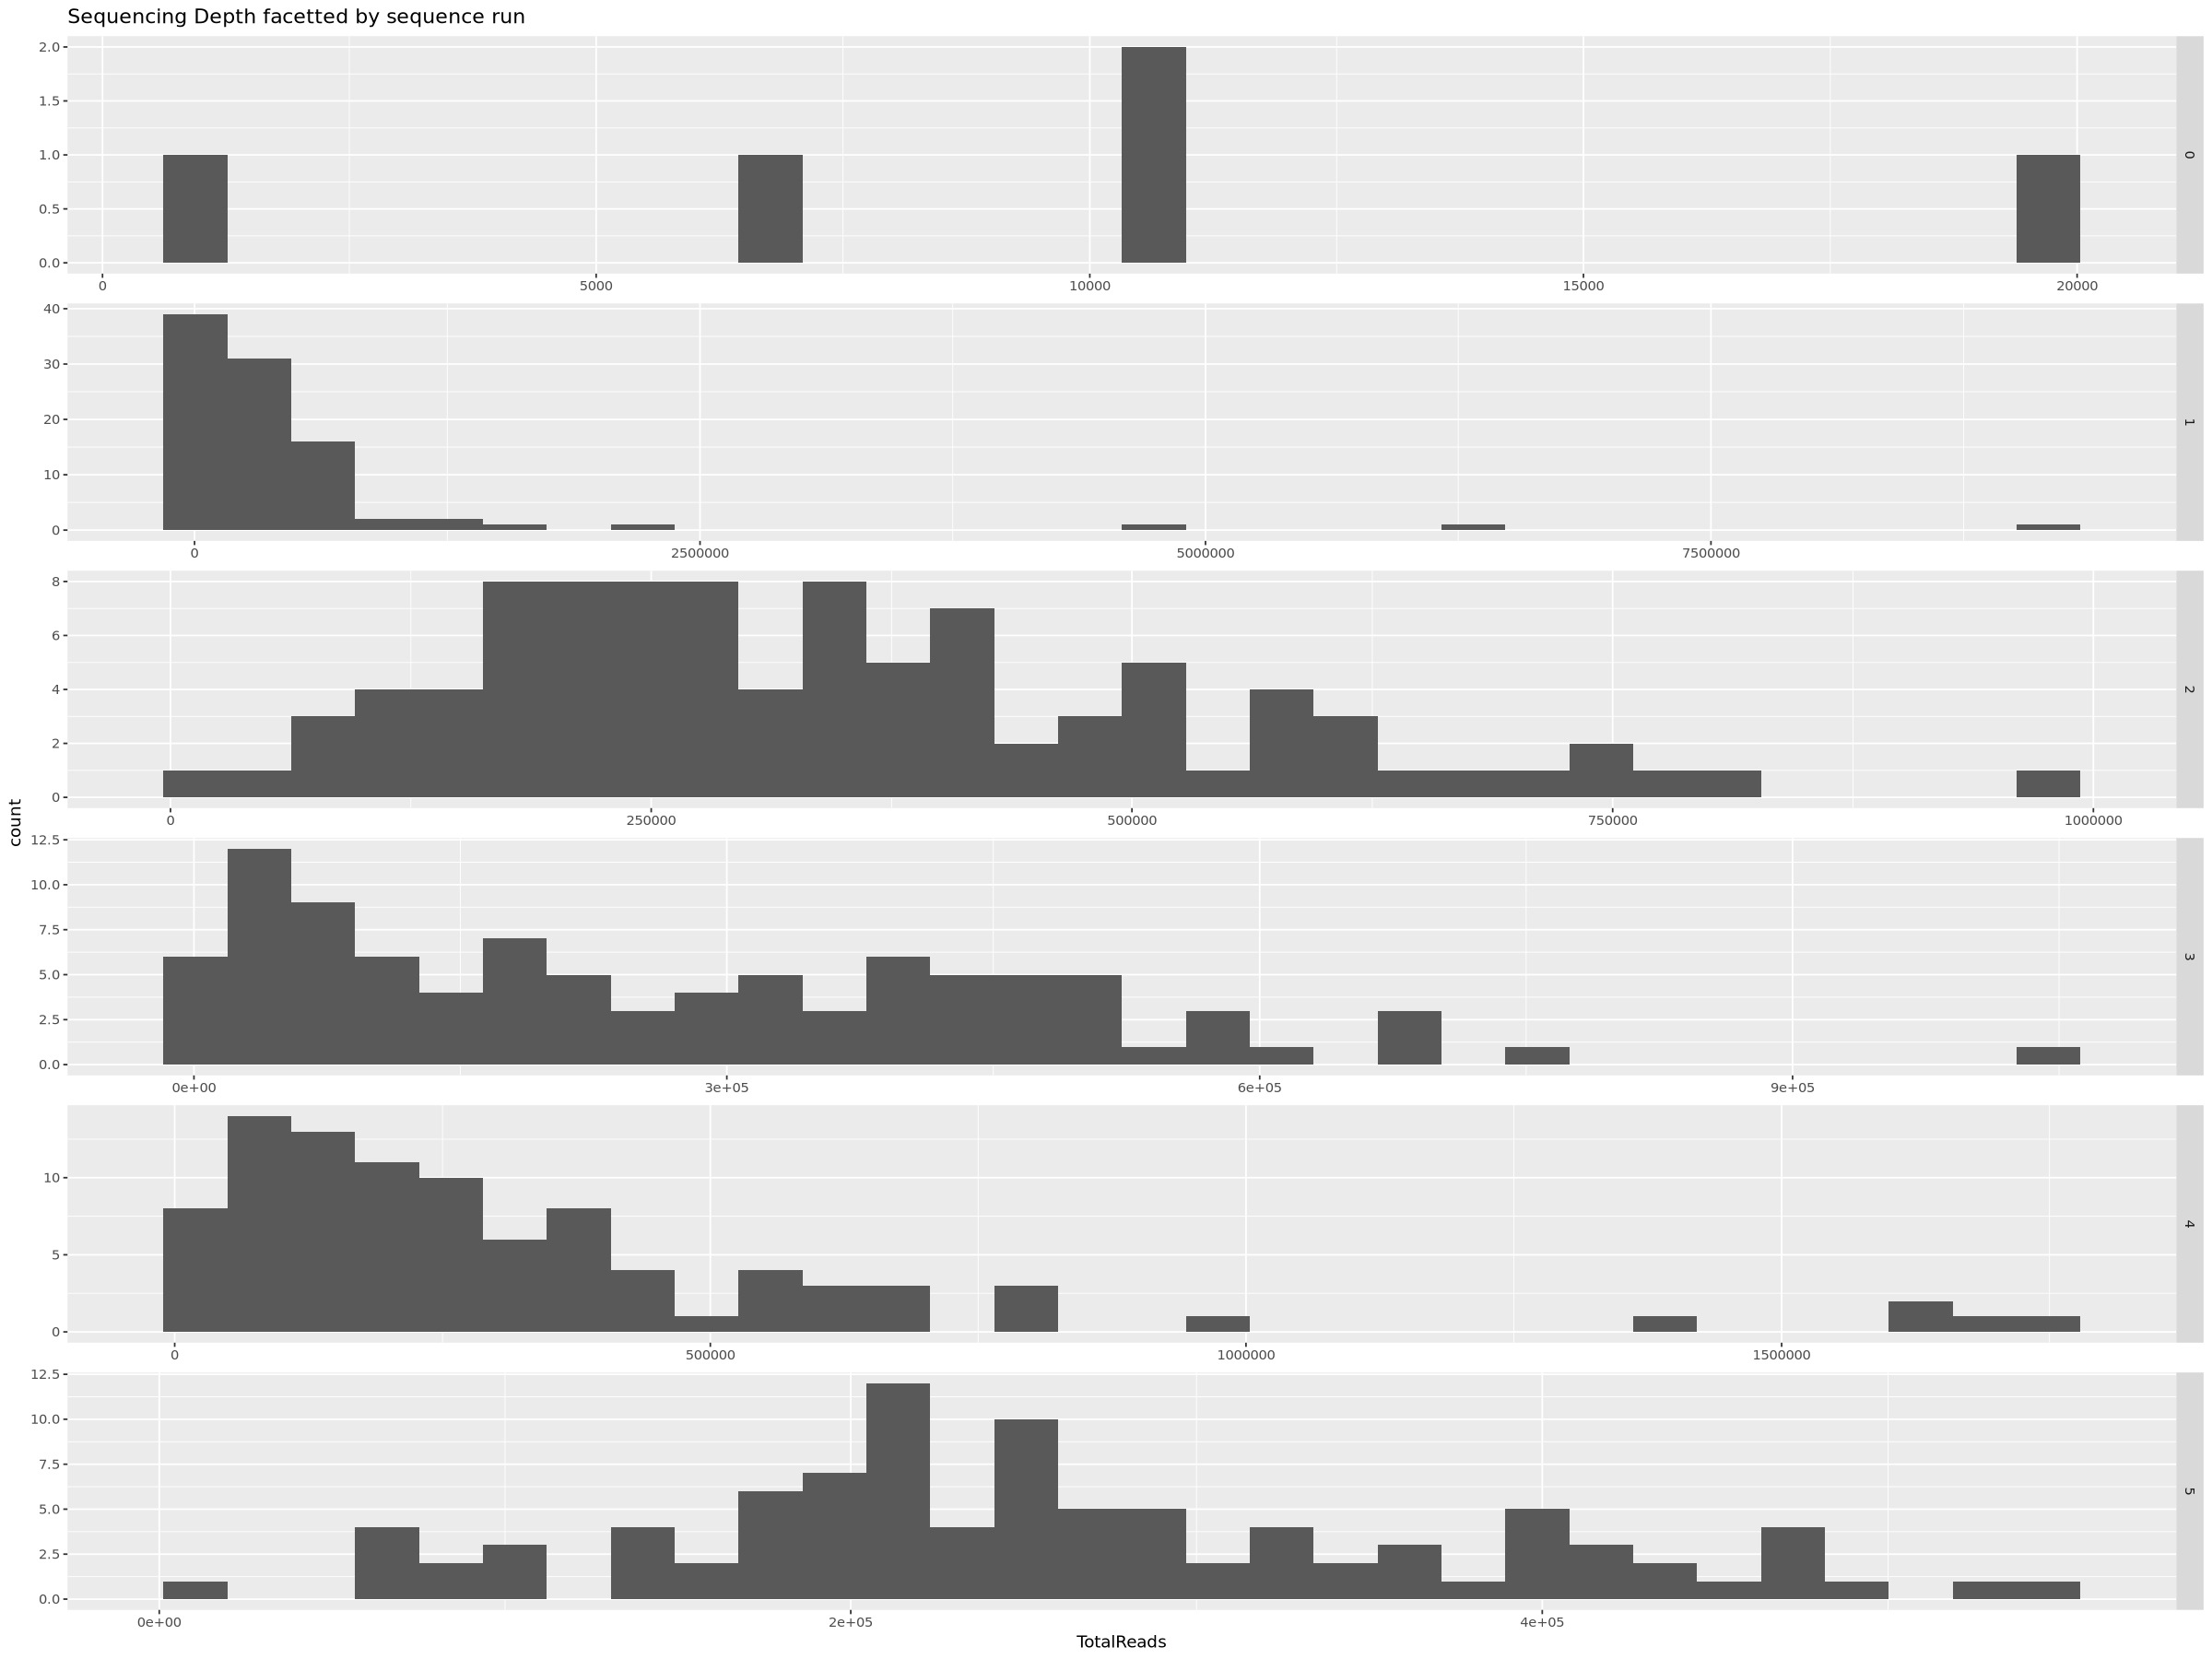

In [36]:
# Check read count
readcount = data.table(as(sample_data(ps), "data.frame"),
                 TotalReads = sample_sums(ps), 
                 keep.rownames = TRUE)
setnames(readcount, "rn", "SampleID")
ggplot(readcount, aes(TotalReads)) + geom_histogram() + ggtitle("Sequencing Depth facetted by sequence run") + facet_wrap(Seq_run ~., strip.position = "right",  ncol = 1, scales="free")  # Set desired font size

### figure notes
- negative controls are listed as seq run 0. they all have less than 2000 reads

In [37]:
total_reads <- print(readcount[order(readcount$TotalReads), c("SampleID", "TotalReads")])

# median reads
median(readcount$TotalReads)

# mean reads
mean(readcount$TotalReads)

# minimum read number
readcount[, min(TotalReads)]

                        SampleID TotalReads
                          <char>      <num>
  1:  012024_BEL_CBC_T1_561_OANN        765
  2:                    Negative        940
  3:  042024_BEL_CBC_T3_960_OFAV       3853
  4:  122022_BEL_CBC_T3_142_MCAV       4868
  5:                  Negative.4       6771
 ---                                       
475:  012024_BEL_CBC_T3_625_SSID    1749091
476: 042024_BEL_CBC_T2_1018_PAST    2096344
477: 082024_BEL_CBC_T3_1562_OFAV    4651047
478: 062024_BEL_CBC_T2_1375_SSID    6257366
479:  092023_BEL_CBC_T2_184_MCAV    9169329


[1] 257489

[1] 348608.4

[1] 765

## clean_phyloseq_object
- remove chloroplast and mitochondrial taxa
- remove singletons

In [38]:
#isolate just bacteria
ps_bac=subset_taxa(ps, Kingdom=="Bacteria")
ps_bac

#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
ps_nochlo

#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")
ps_nomit

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 104196 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 104196 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 78949 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 78949 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46684 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46684 taxa by 6 taxonomic ranks ]

In [39]:
#removing any taxa that don't show up in any samples to speed up the process

#maybe I should up to 1 to remove singletons
ps_prune <- prune_taxa(taxa_sums(ps_nomit) > 0, ps_nomit)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46551 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46551 taxa by 6 taxonomic ranks ]

## what_taxa_show_up?

Warning message:
“Some columns are a multi-column type (such as a matrix column): [1, 2, 3, 4, 5, 6]. setDT will retain these columns as-is but subsequent operations like grouping and joining may fail. Please consider as.data.table() instead which will create a new column for each embedded column.”
Warning message:
“Some columns are a multi-column type (such as a matrix column): [1, 2, 3, 4, 5, 6]. setDT will retain these columns as-is but subsequent operations like grouping and joining may fail. Please consider as.data.table() instead which will create a new column for each embedded column.”
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


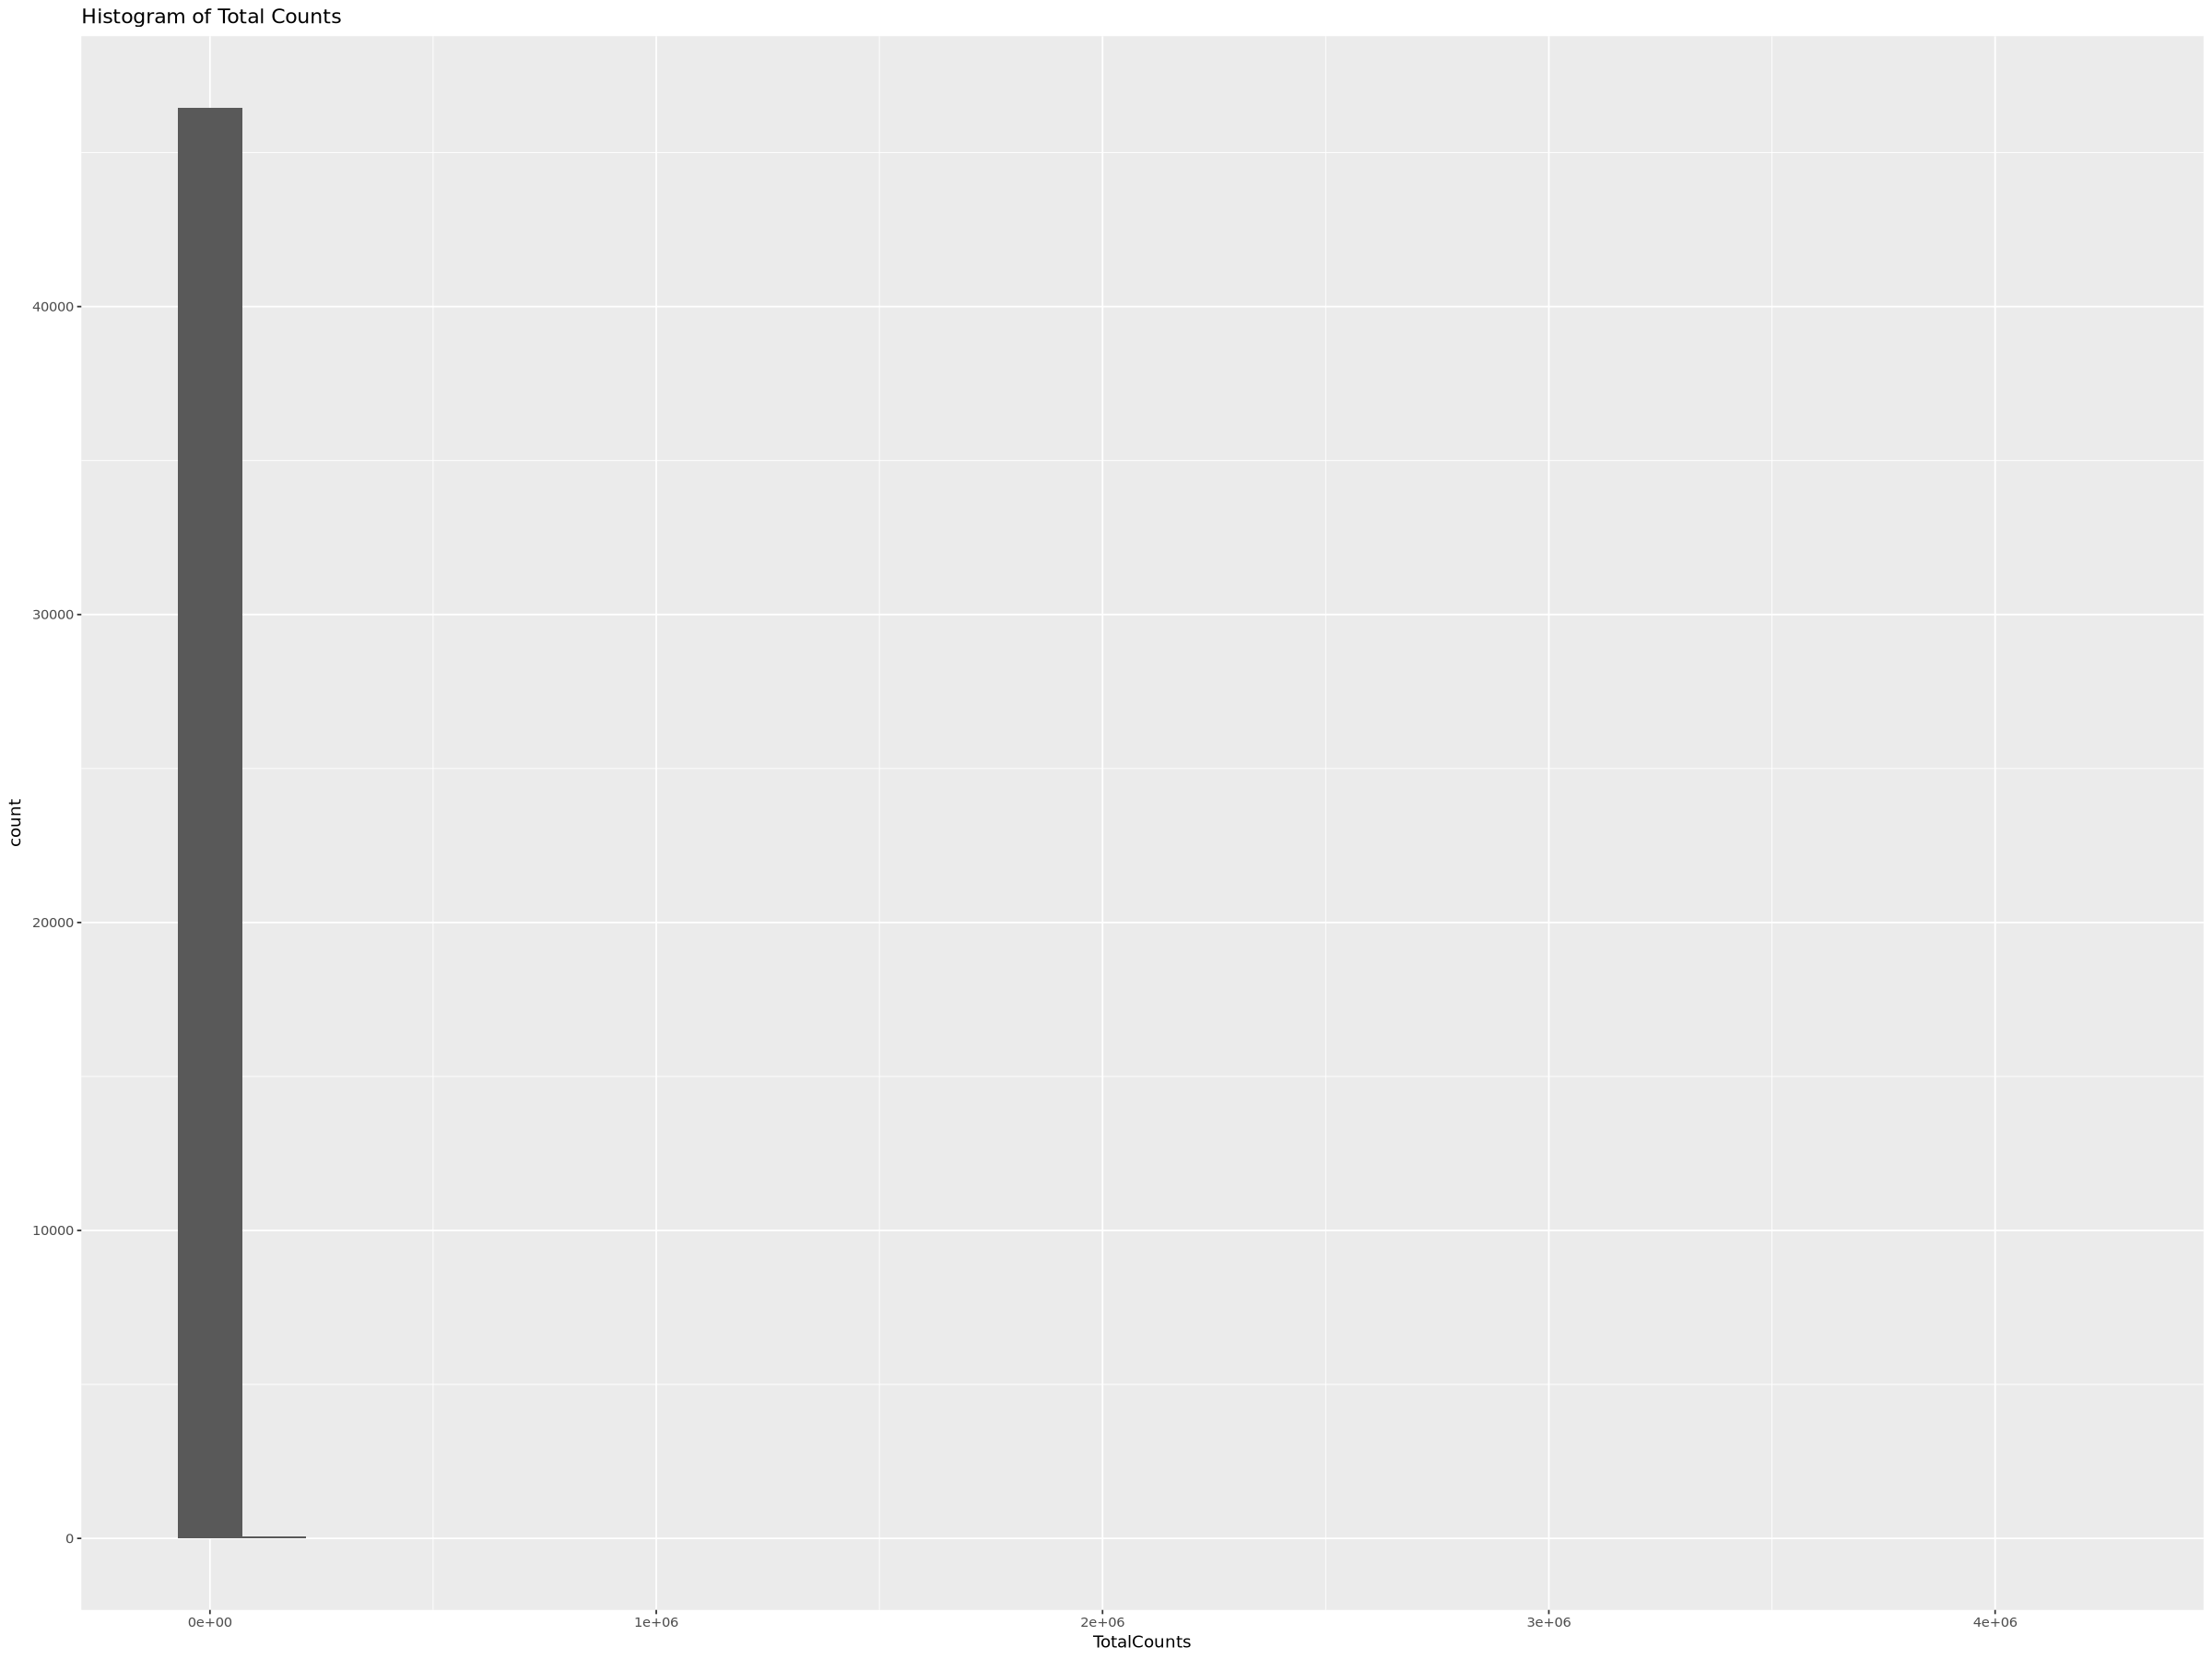

In [40]:
tdt = data.table(tax_table(ps_prune),
                 TotalCounts = taxa_sums(ps_prune),
                 OTU = taxa_names(ps_prune))
ggplot(tdt, aes(TotalCounts)) + 
  geom_histogram() + 
  ggtitle("Histogram of Total Counts")

### figure notes
- most otus show up less than 1E06 times

## any_super_rare_OTUs?

In [41]:
# How many singletons?
tdt[(TotalCounts <= 0), .N]

# already filtered for otus that don't show up in any samples
#313 in ps
tdt[(TotalCounts <= 1), .N]

# 5 OTU singletons in ps_prine
#there are 325 OTU in ps

# How many doubletons?
tdt[(TotalCounts <= 2), .N]
# 787 doubleton otus in ps_prune
#there are 2964 otu that only show up twice

[1] 0

[1] 5

[1] 787

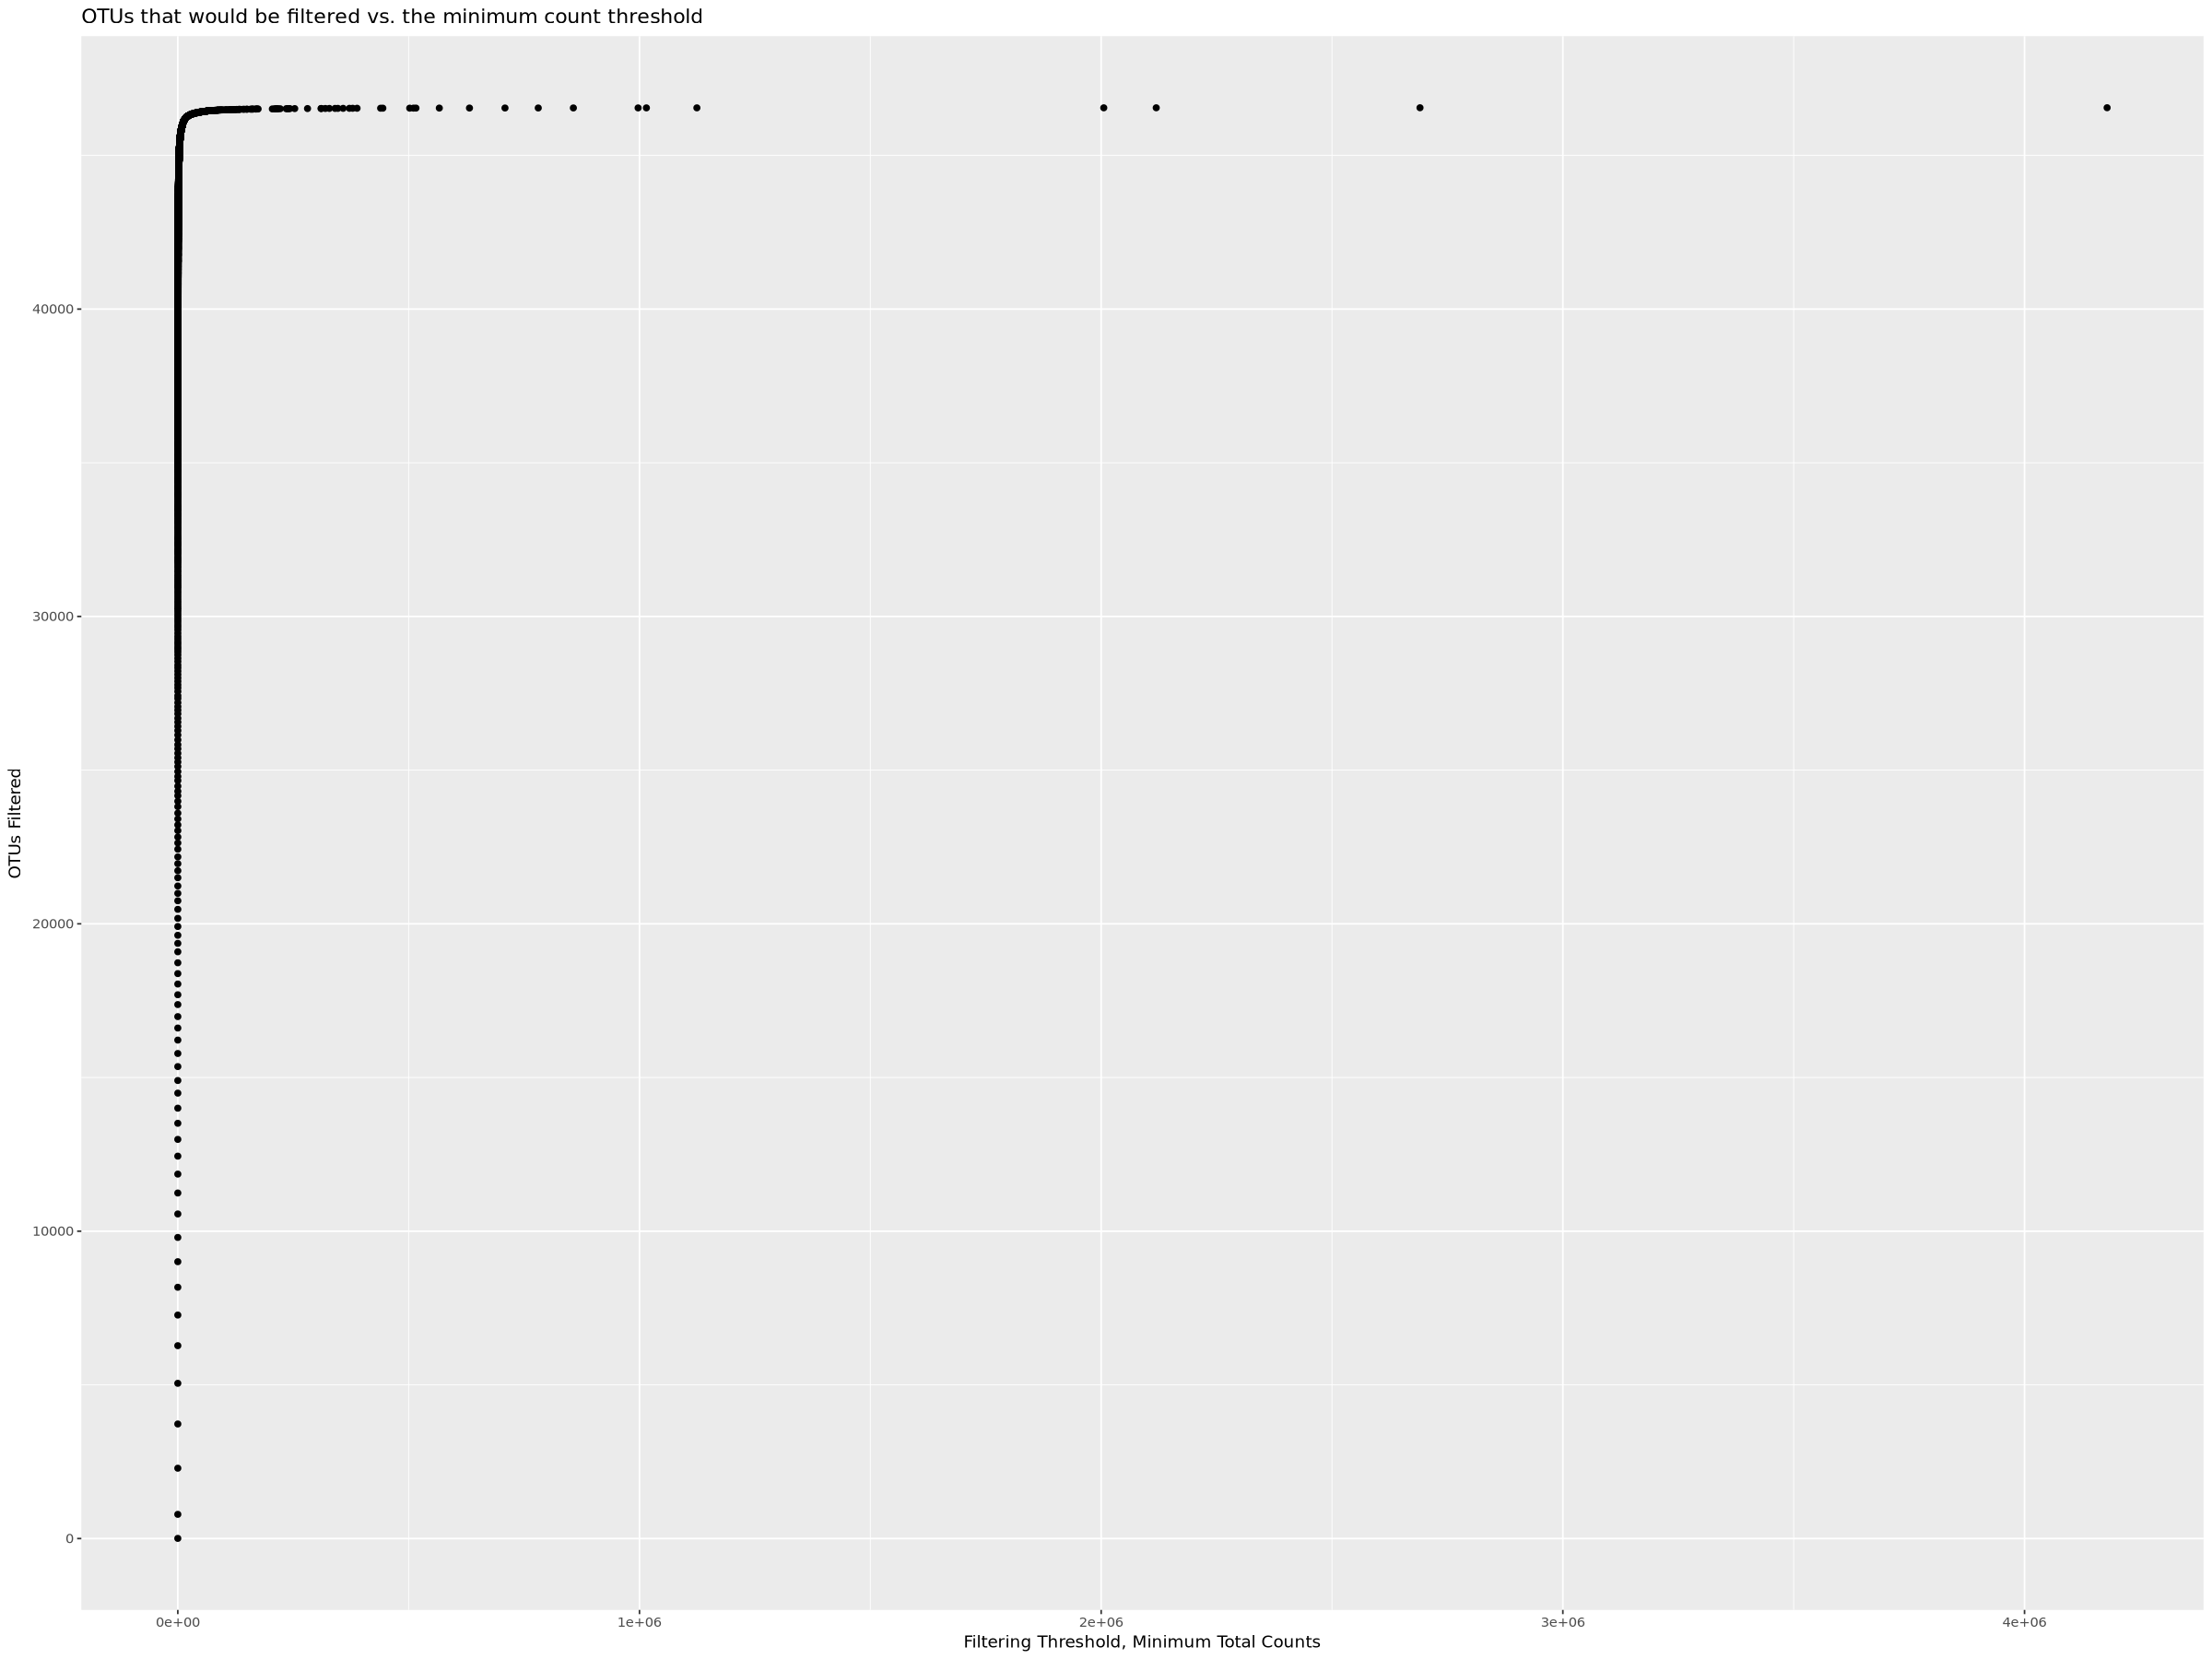

In [42]:
# taxa cumulative sum
taxcumsum = tdt[, .N, by = TotalCounts]
setkey(taxcumsum, TotalCounts)
taxcumsum[, CumSum := cumsum(N)]
# Define the plot
pCumSum = ggplot(taxcumsum, aes(TotalCounts, CumSum)) + 
  geom_point() +
  xlab("Filtering Threshold, Minimum Total Counts") +
  ylab("OTUs Filtered") +
  ggtitle("OTUs that would be filtered vs. the minimum count threshold")
pCumSum

Warning message:
“Removed 553 rows containing missing values or values outside the scale range
(`geom_point()`).”


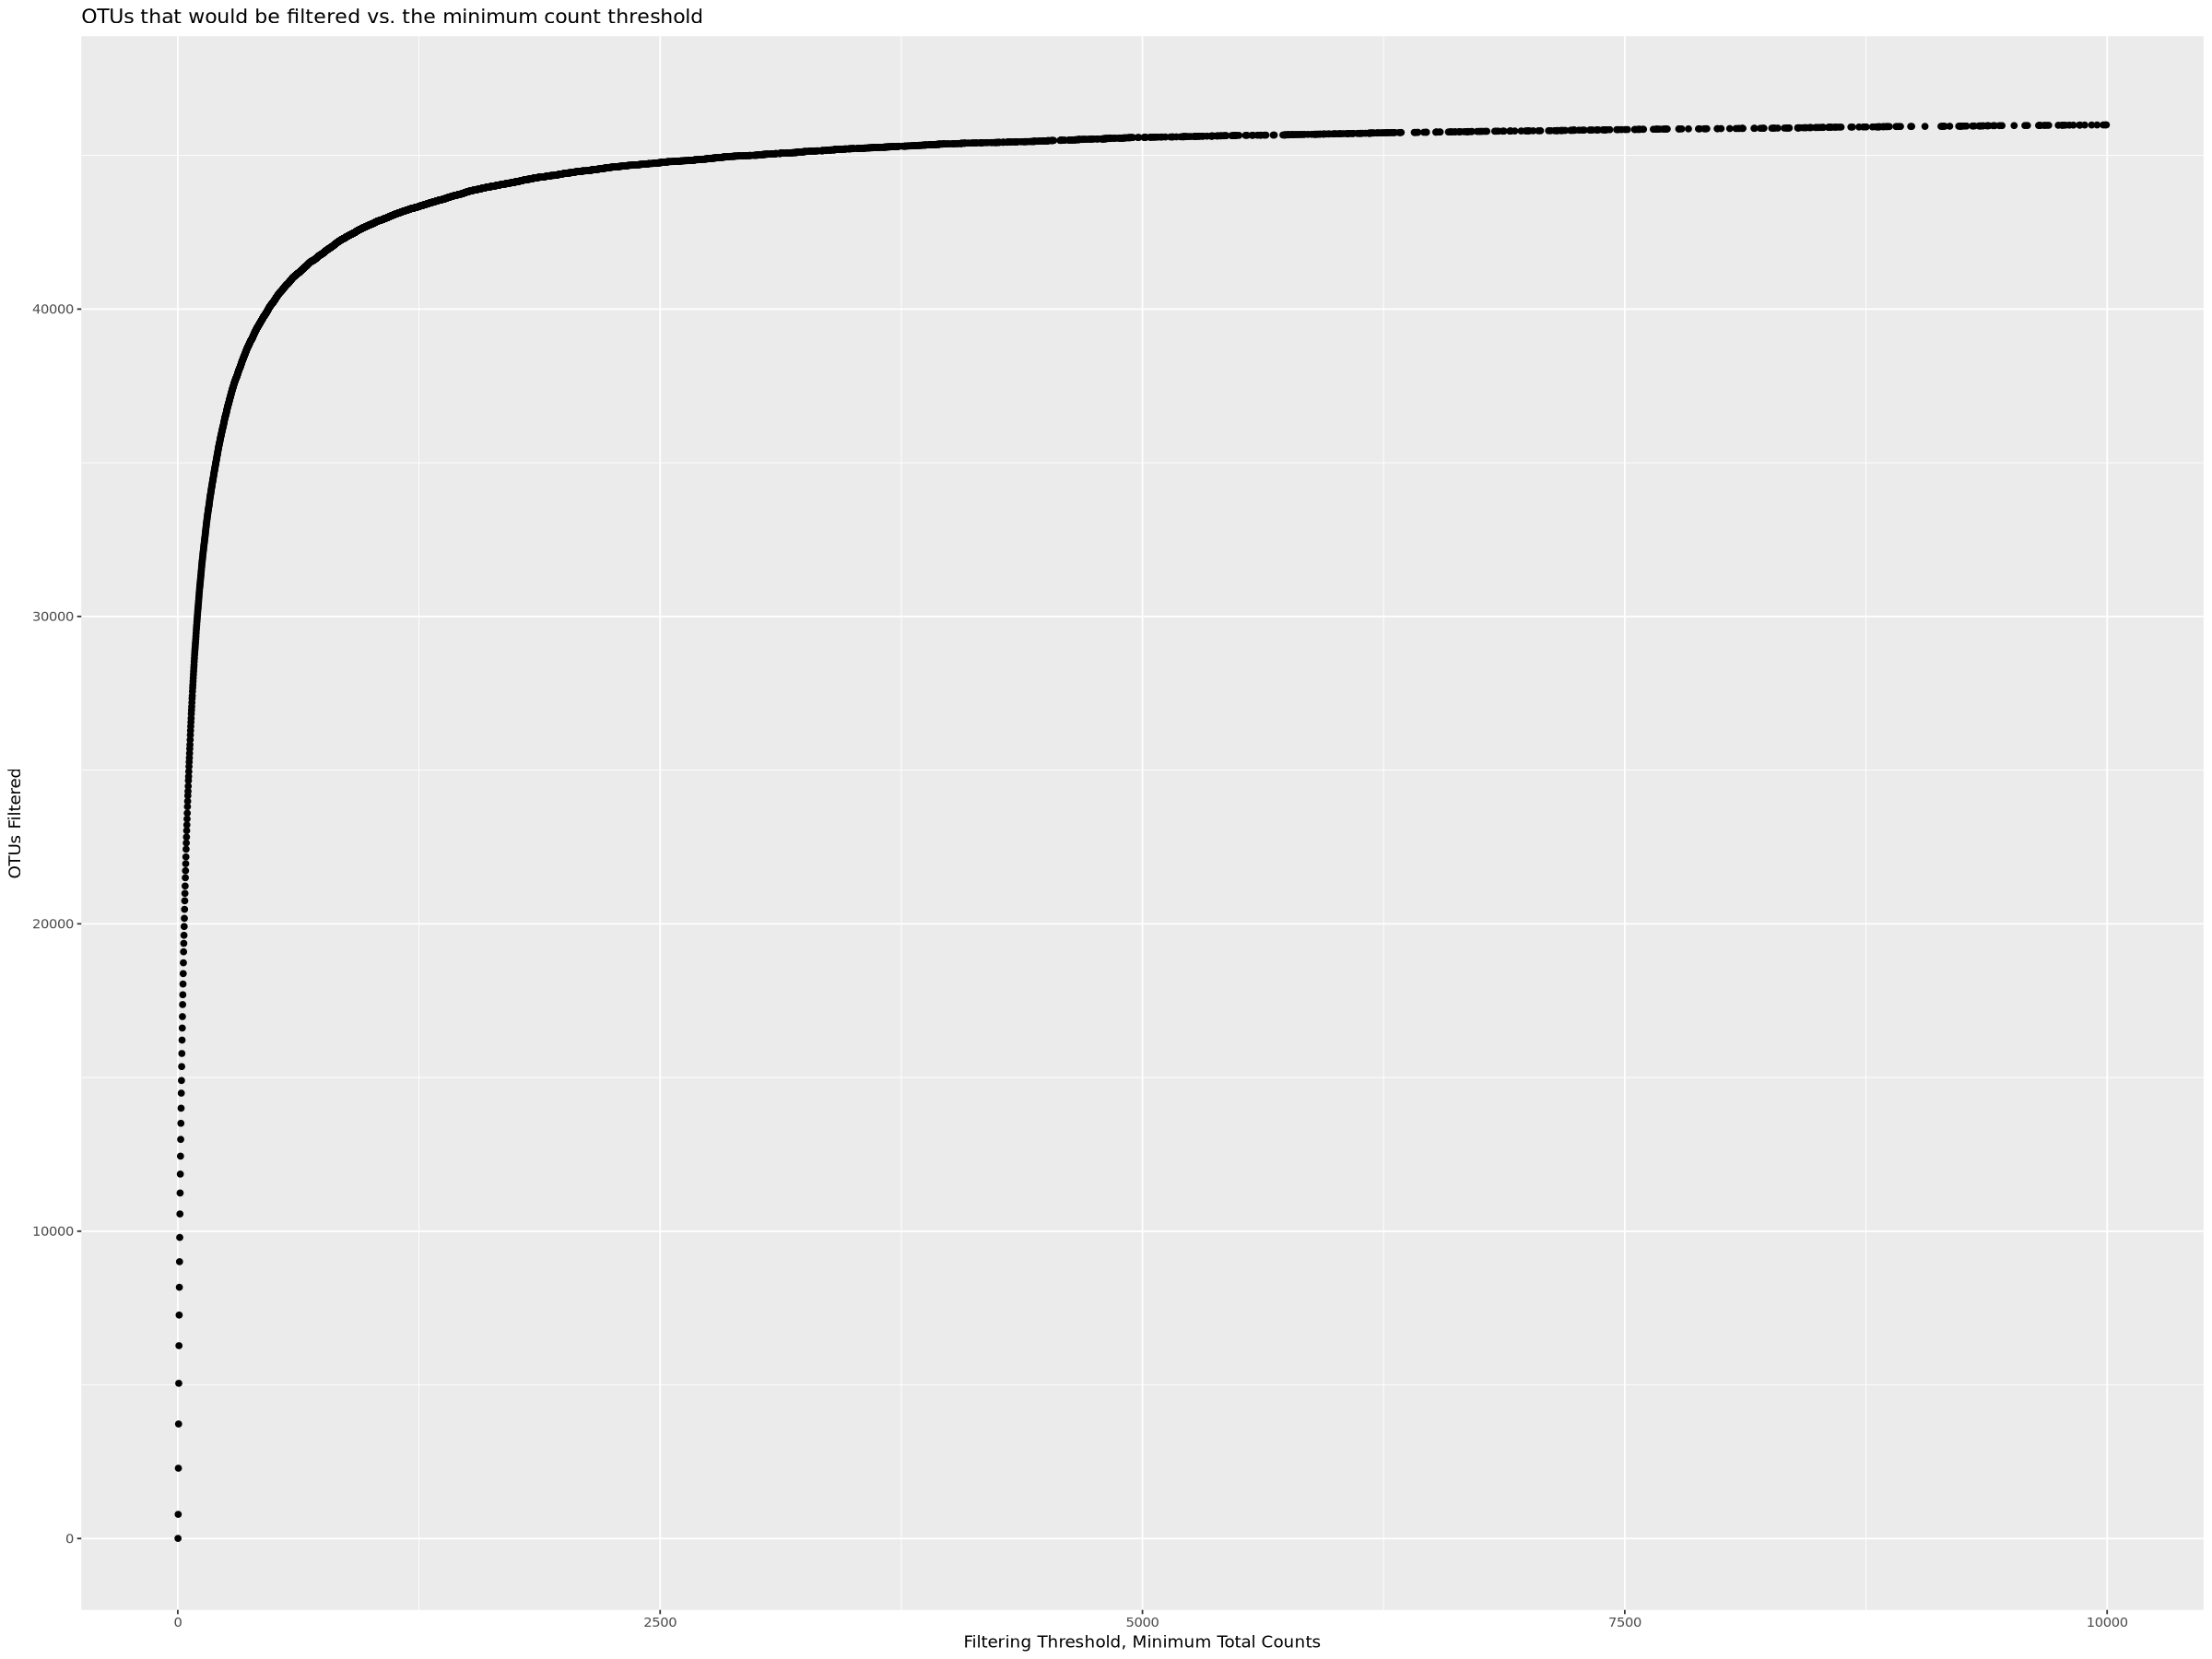

In [43]:
# Zoom-in to 0-10000 otu counts
pCumSum + xlim(0, 10000)

### figure notes 

**I dont really know what the point of plotting this is https://evomics.org/wp-content/uploads/2016/01/phyloseq-Lab-01-Answers.html**

- cumulative sum of OTUs that would be filtered at every possible value of such a threshold, from zero to the most-observed OTU.

- this plot shows us that if I filter out OTu's that appear less than 1000 times then I will be losing 40,000 OTUs

- goal is to justify and document decision for filtering. The goal of filtering is to remove noise from the data, in this case noisy variables that are unlikely to provide any useful information. Our criteria for this filtering should not include variables from which we want to infer biological insights later on. Why is that?




# rarefaction_curves
- test out if sequencing depth was optimal for revealing the OTU species that exist in each sample
- As the curve flattens, it suggests that the sequencing data volume is optimised (additional data would yield only a minimal increase in new OTUs)
- rarefaction curve could be used to determined whether the sequencing depth cover microbial diversity of the sample

## rarefaction_curve_ps
- all species and runs in the same plot

- step: tells R to evaluate diversity at X number of reads (decreasing this makes curves smoother but takes longer).
- sample: Subsample size. If specified, a vertical line is drawn at this sample size, along with horizontal lines marking rarefied species richness.
- label: Adds labels to the curves using the row names of your dataset.

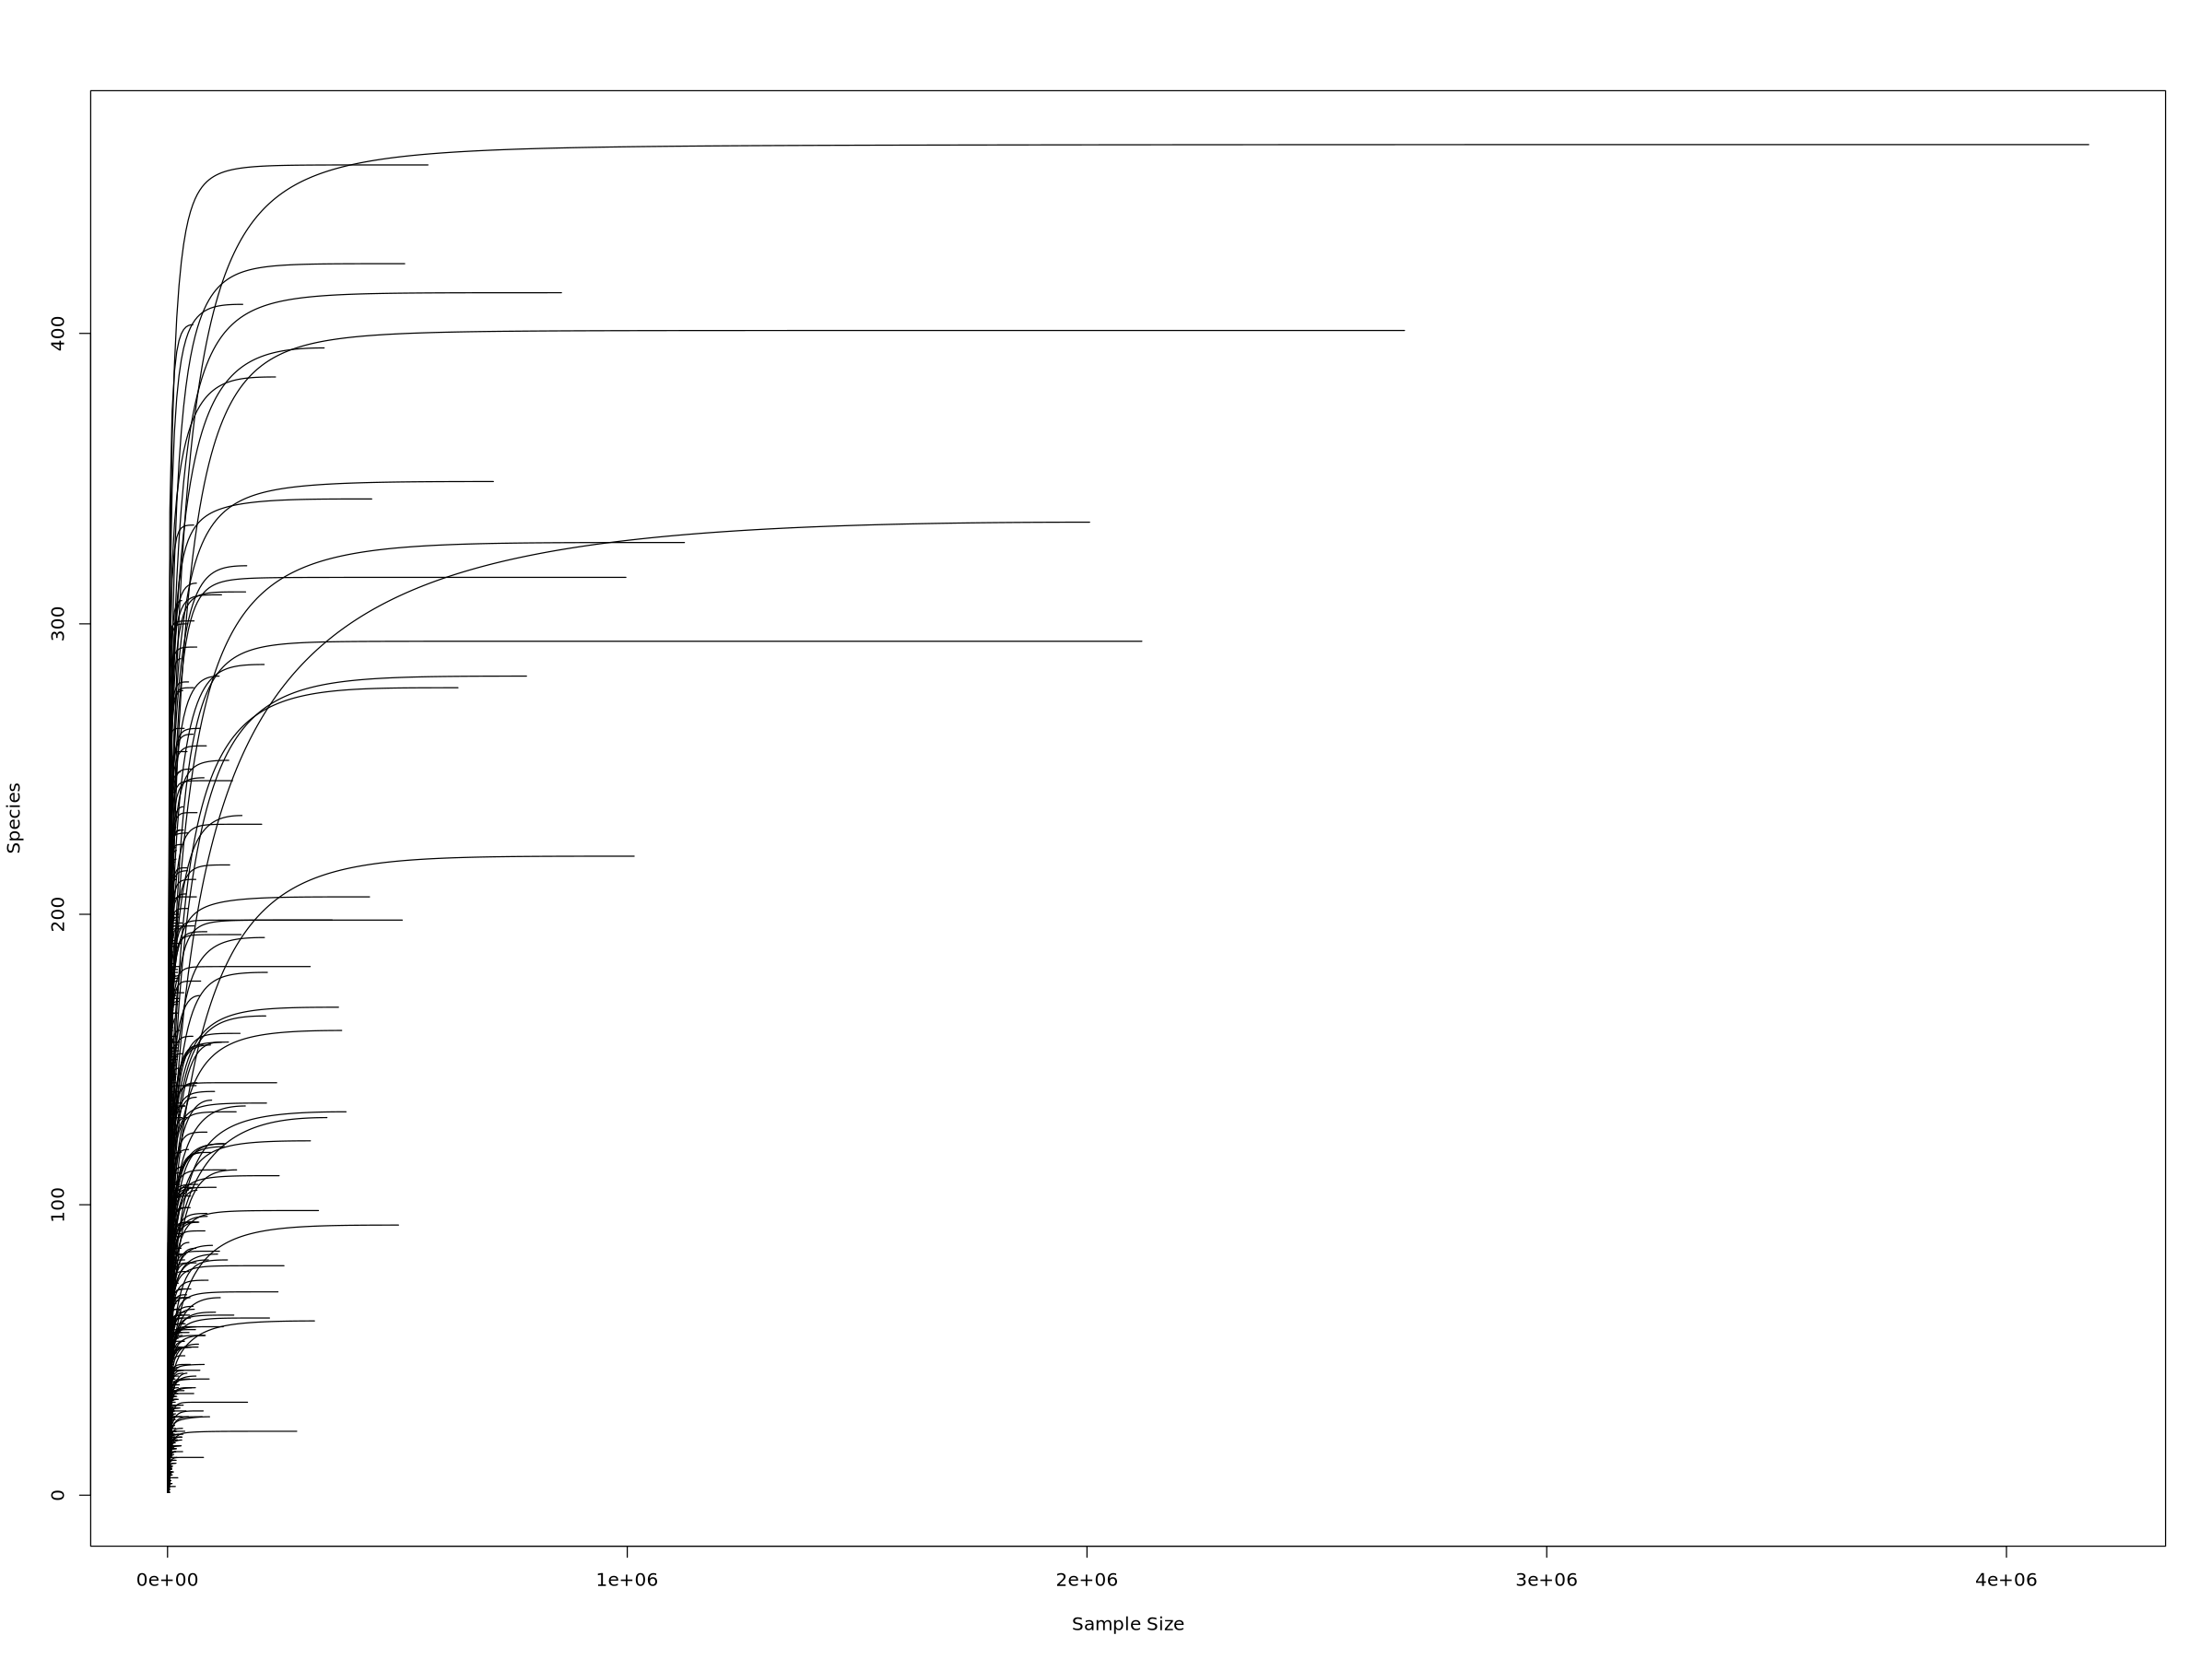

In [25]:
otu.rare = otu_table(ps_prune)
otu.rare = as.data.frame(t(otu.rare))
sample_names = rownames(otu.rare)

# we will use vegan rarecurve 
otu.rarecurve = rarecurve(otu.rare, step = 5000, label = FALSE)

## rarefaction_curve_ps_no1
- genrating a rarefaction curve for ps_16S without run1
- hopefully this will show that more samples were successful outside of run1

In [33]:
#remove seq run1

ps_no1 <- subset_samples(ps_prune, Seq_run != "1")
ps_no1

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46551 taxa and 384 samples ]
sample_data() Sample Data:       [ 384 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46551 taxa by 6 taxonomic ranks ]

empty rows removed



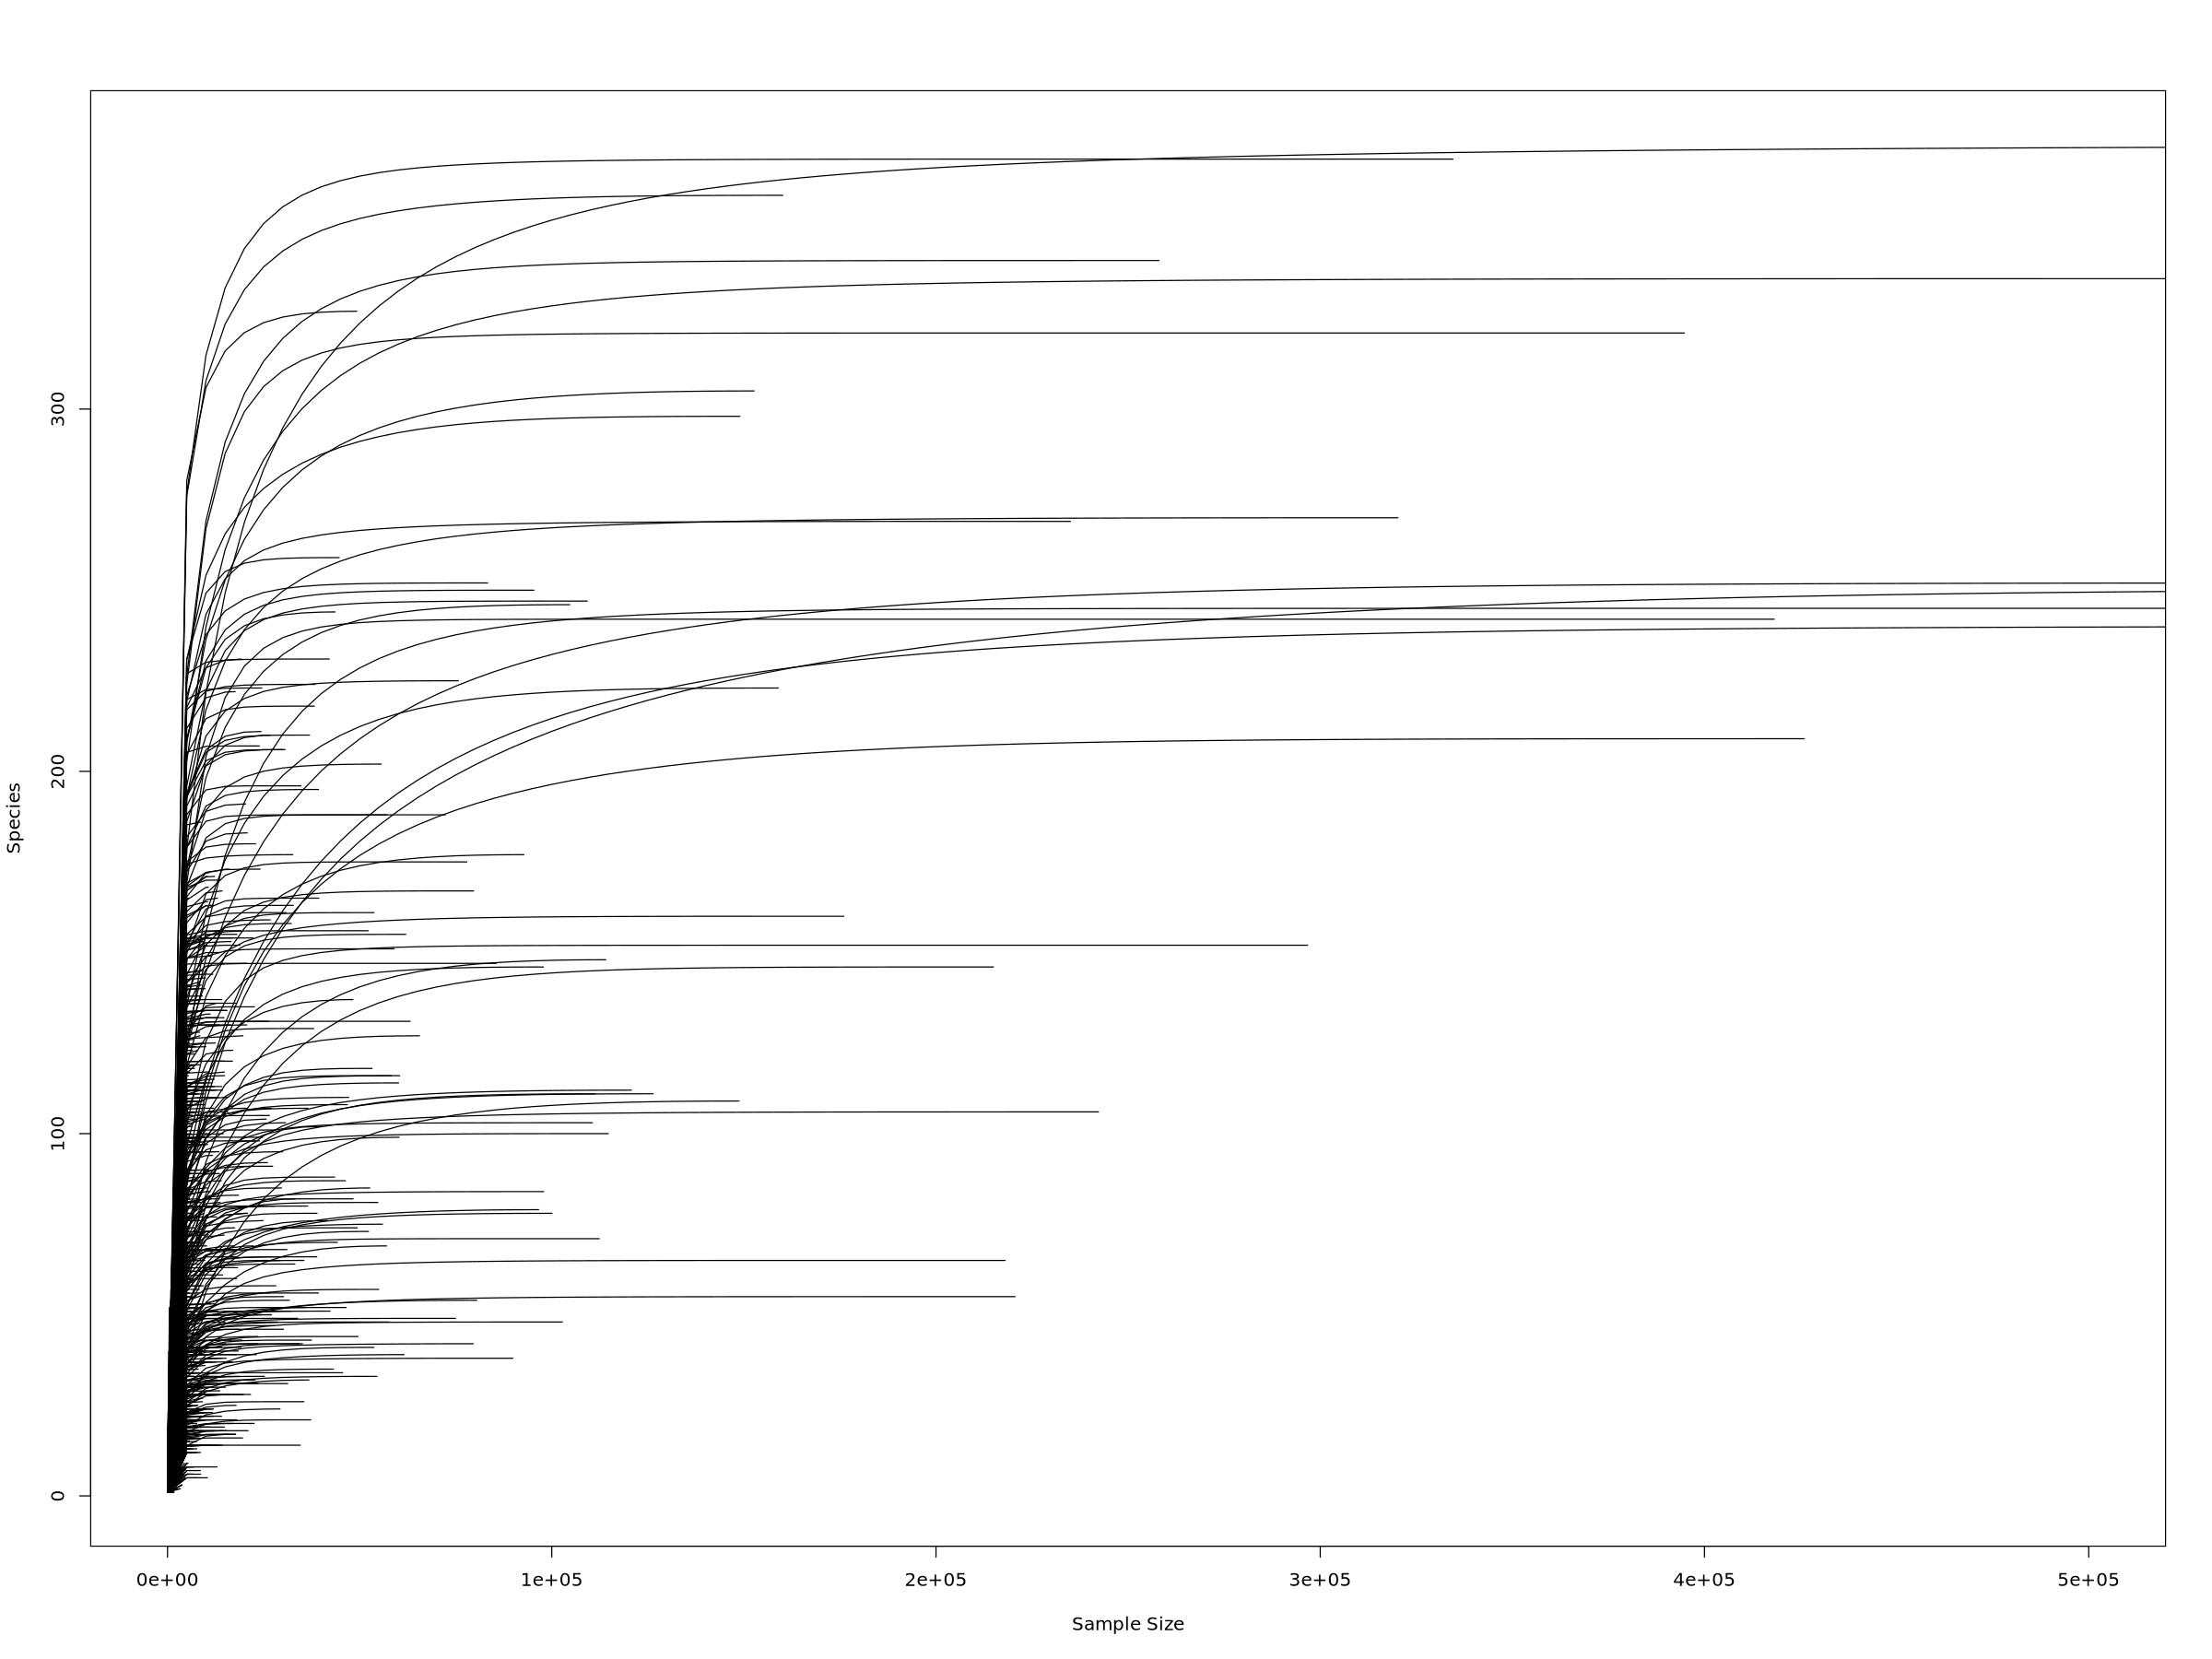

In [32]:
otu.rare.no1 = otu_table(ps_no1)
otu.rare.no1 = as.data.frame(t(otu.rare.no1))
sample_names = rownames(otu.rare.no1)

# we will use vegan rarecurve zooming in to 500K
# Zoom in directly using the xlim argument

otu.rarecurve.no1 = rarecurve(otu.rare.no1, step = 5000, label = FALSE, xlim = c(0, 500000))

### figure notes
- this figure shows that as the number of samples within a comunity (x) increases, the number of species identified increased until an upper limit is reached.
- **how can I ID which samples never reached the critical point?**


## species_rarefaction_curve_ps_no1
-(not seq run 1) to parse out which samples had successful sequencing depths
### notes:
- xlim (0,50K) enables me to see that some samples do not pass rarafaction curve test

- **species plots**
- some samples in every species did not pass rarefaction curves

In [60]:
ps_past_no1 <- subset_samples(ps_no1, Species == "PAST")
ps_mcav_no1 <- subset_samples(ps_no1, Species == "MCAV")
ps_pstr_no1 <- subset_samples(ps_no1, Species == "PSTR")
ps_ssid_no1 <- subset_samples(ps_no1, Species == "SSID")

empty rows removed



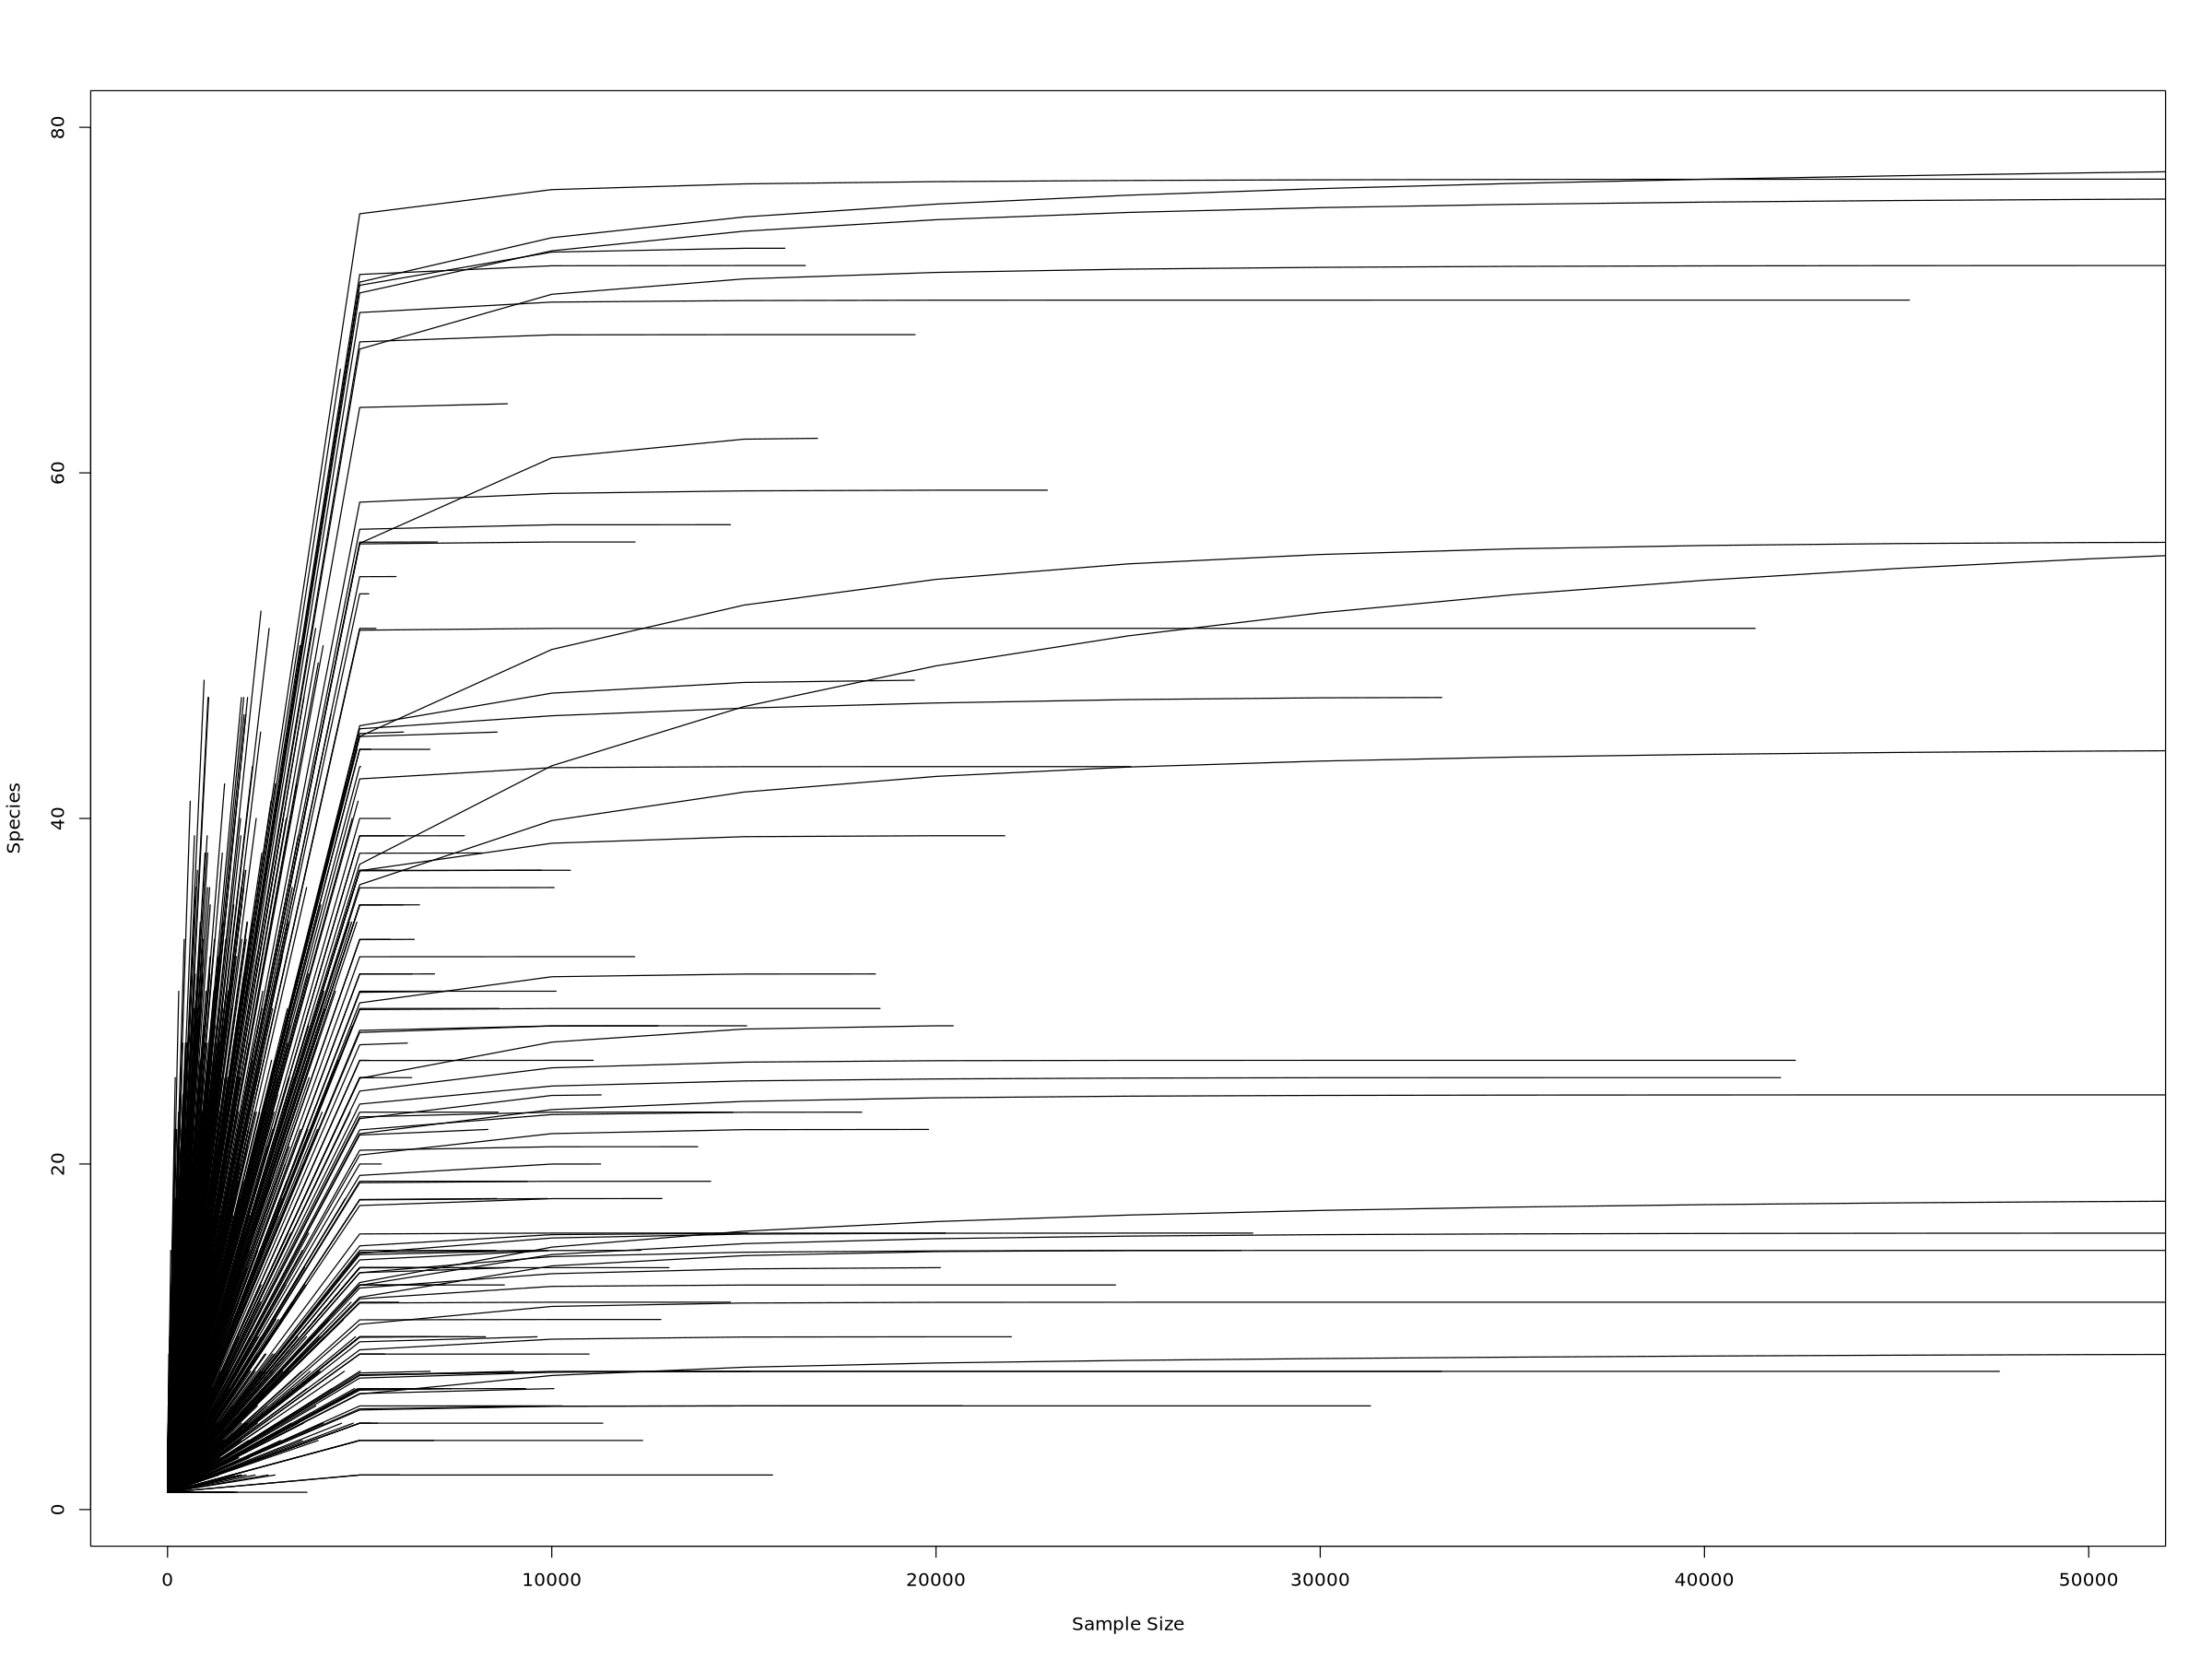

In [67]:
otu.past.no1 = otu_table(ps_past_no1)
otu.past.no1 = as.data.frame(t(otu.past.no1))
sample_names = rownames(otu.past.no1)

# we will use vegan rarecurve zooming in to 500K
# Zoom in directly using the xlim argument

otu.pastcurve.no1 = rarecurve(otu.past.no1, step = 5000, label = FALSE, xlim = c(0, 50000))

empty rows removed



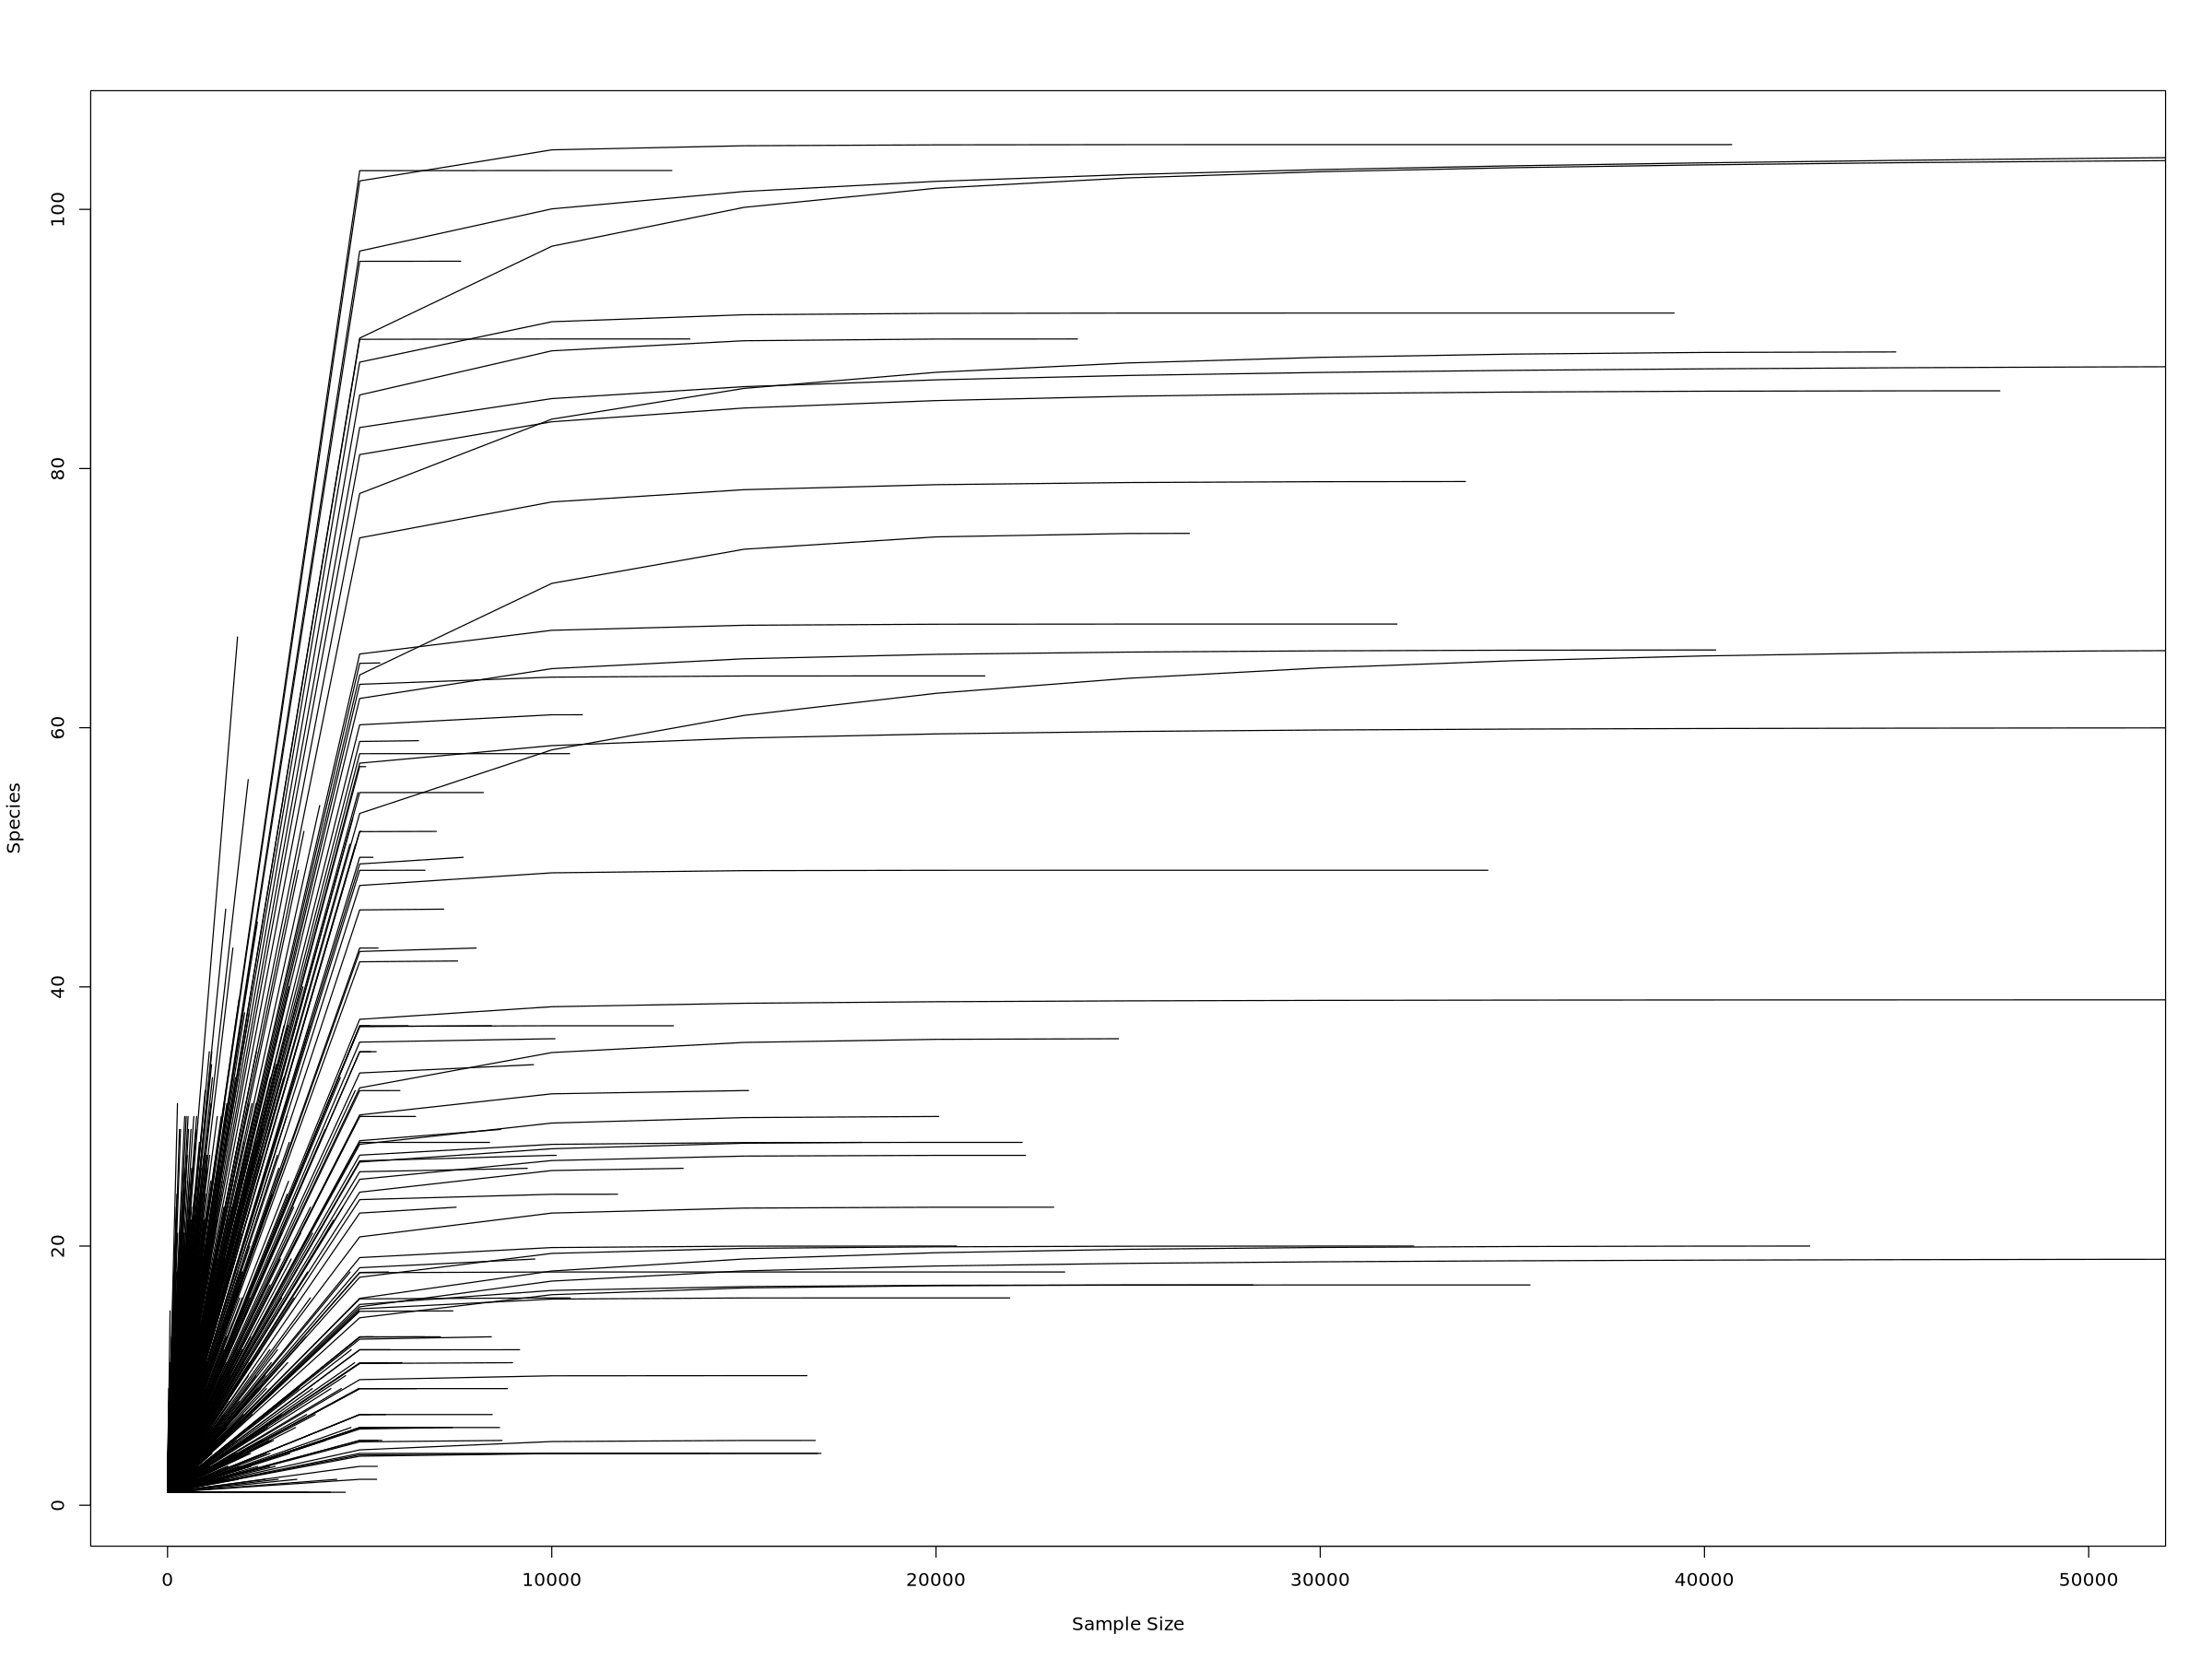

In [68]:
otu.mcav.no1 = otu_table(ps_mcav_no1)
otu.mcav.no1 = as.data.frame(t(otu.mcav.no1))
sample_names = rownames(otu.mcav.no1)

# we will use vegan rarecurve zooming in to 500K
# Zoom in directly using the xlim argument

otu.mcavcurve.no1 = rarecurve(otu.mcav.no1, step = 5000, label = FALSE, xlim = c(0, 50000))

empty rows removed



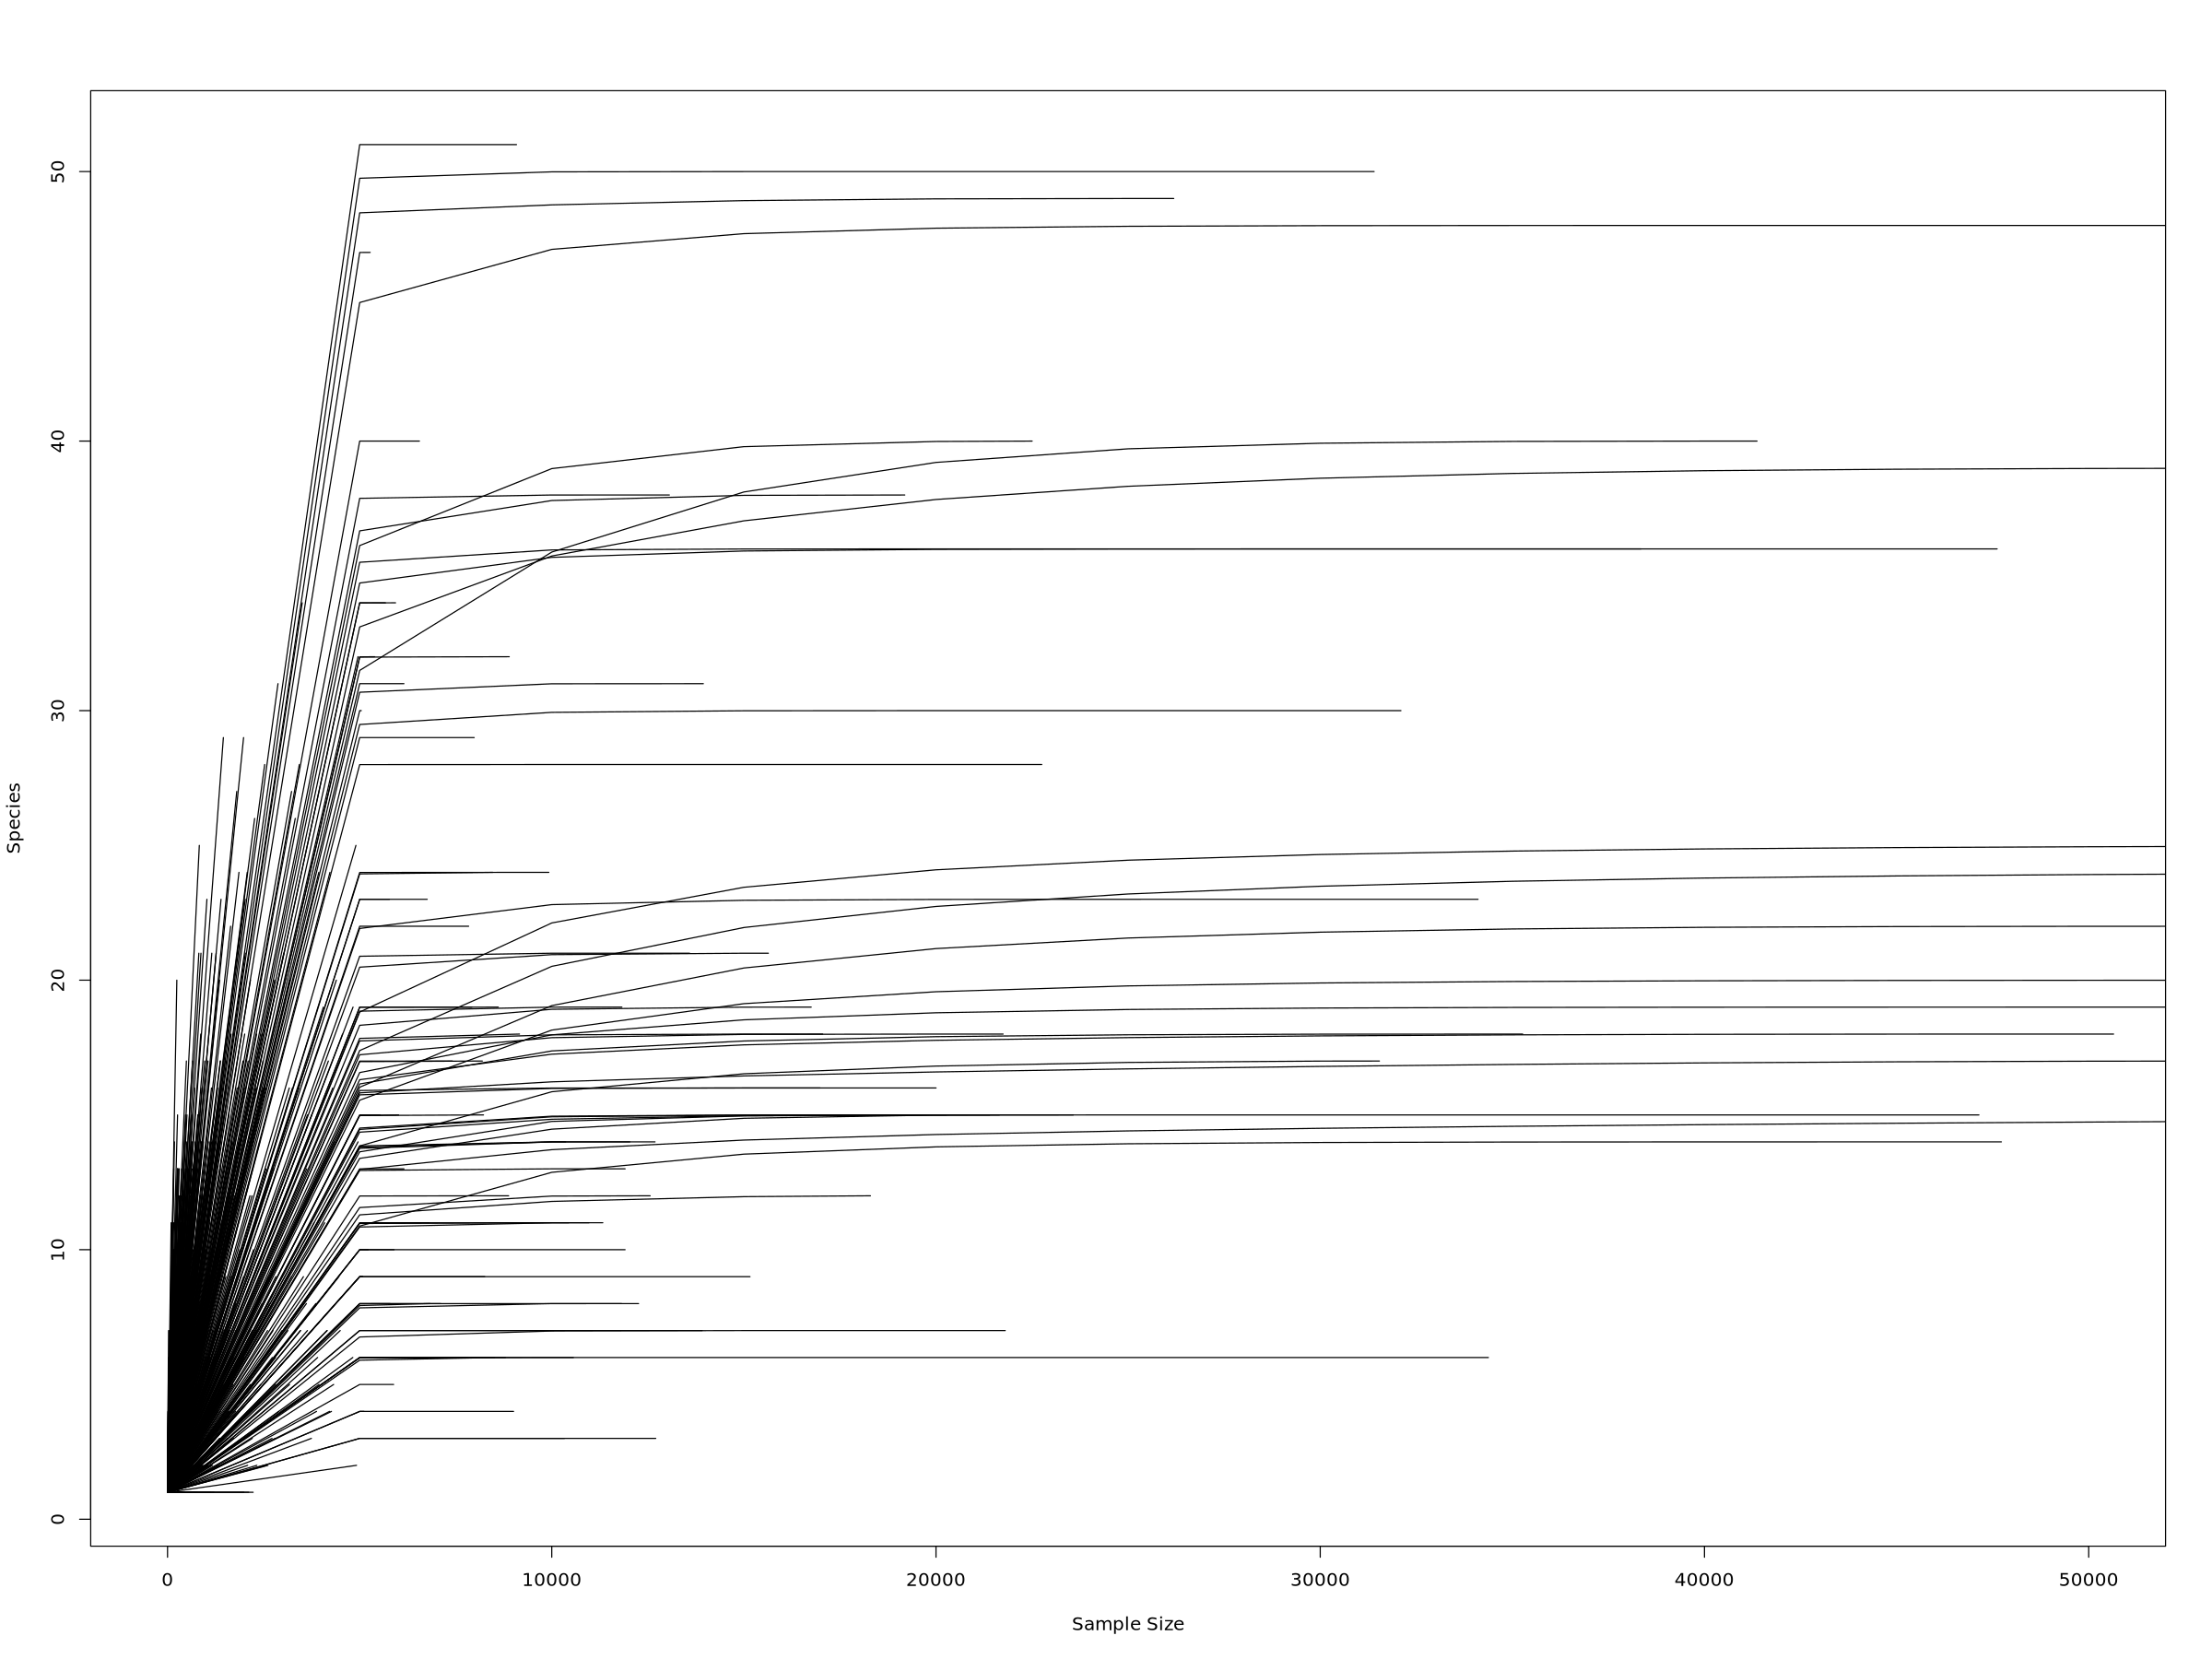

In [66]:
otu.pstr.no1 = otu_table(ps_pstr_no1)
otu.pstr.no1 = as.data.frame(t(otu.pstr.no1))
sample_names = rownames(otu.pstr.no1)

# we will use vegan rarecurve zooming in to 500K
# Zoom in directly using the xlim argument

otu.pstrcurve.no1 = rarecurve(otu.pstr.no1, step = 5000, label = FALSE, xlim = c(0, 50000))

empty rows removed



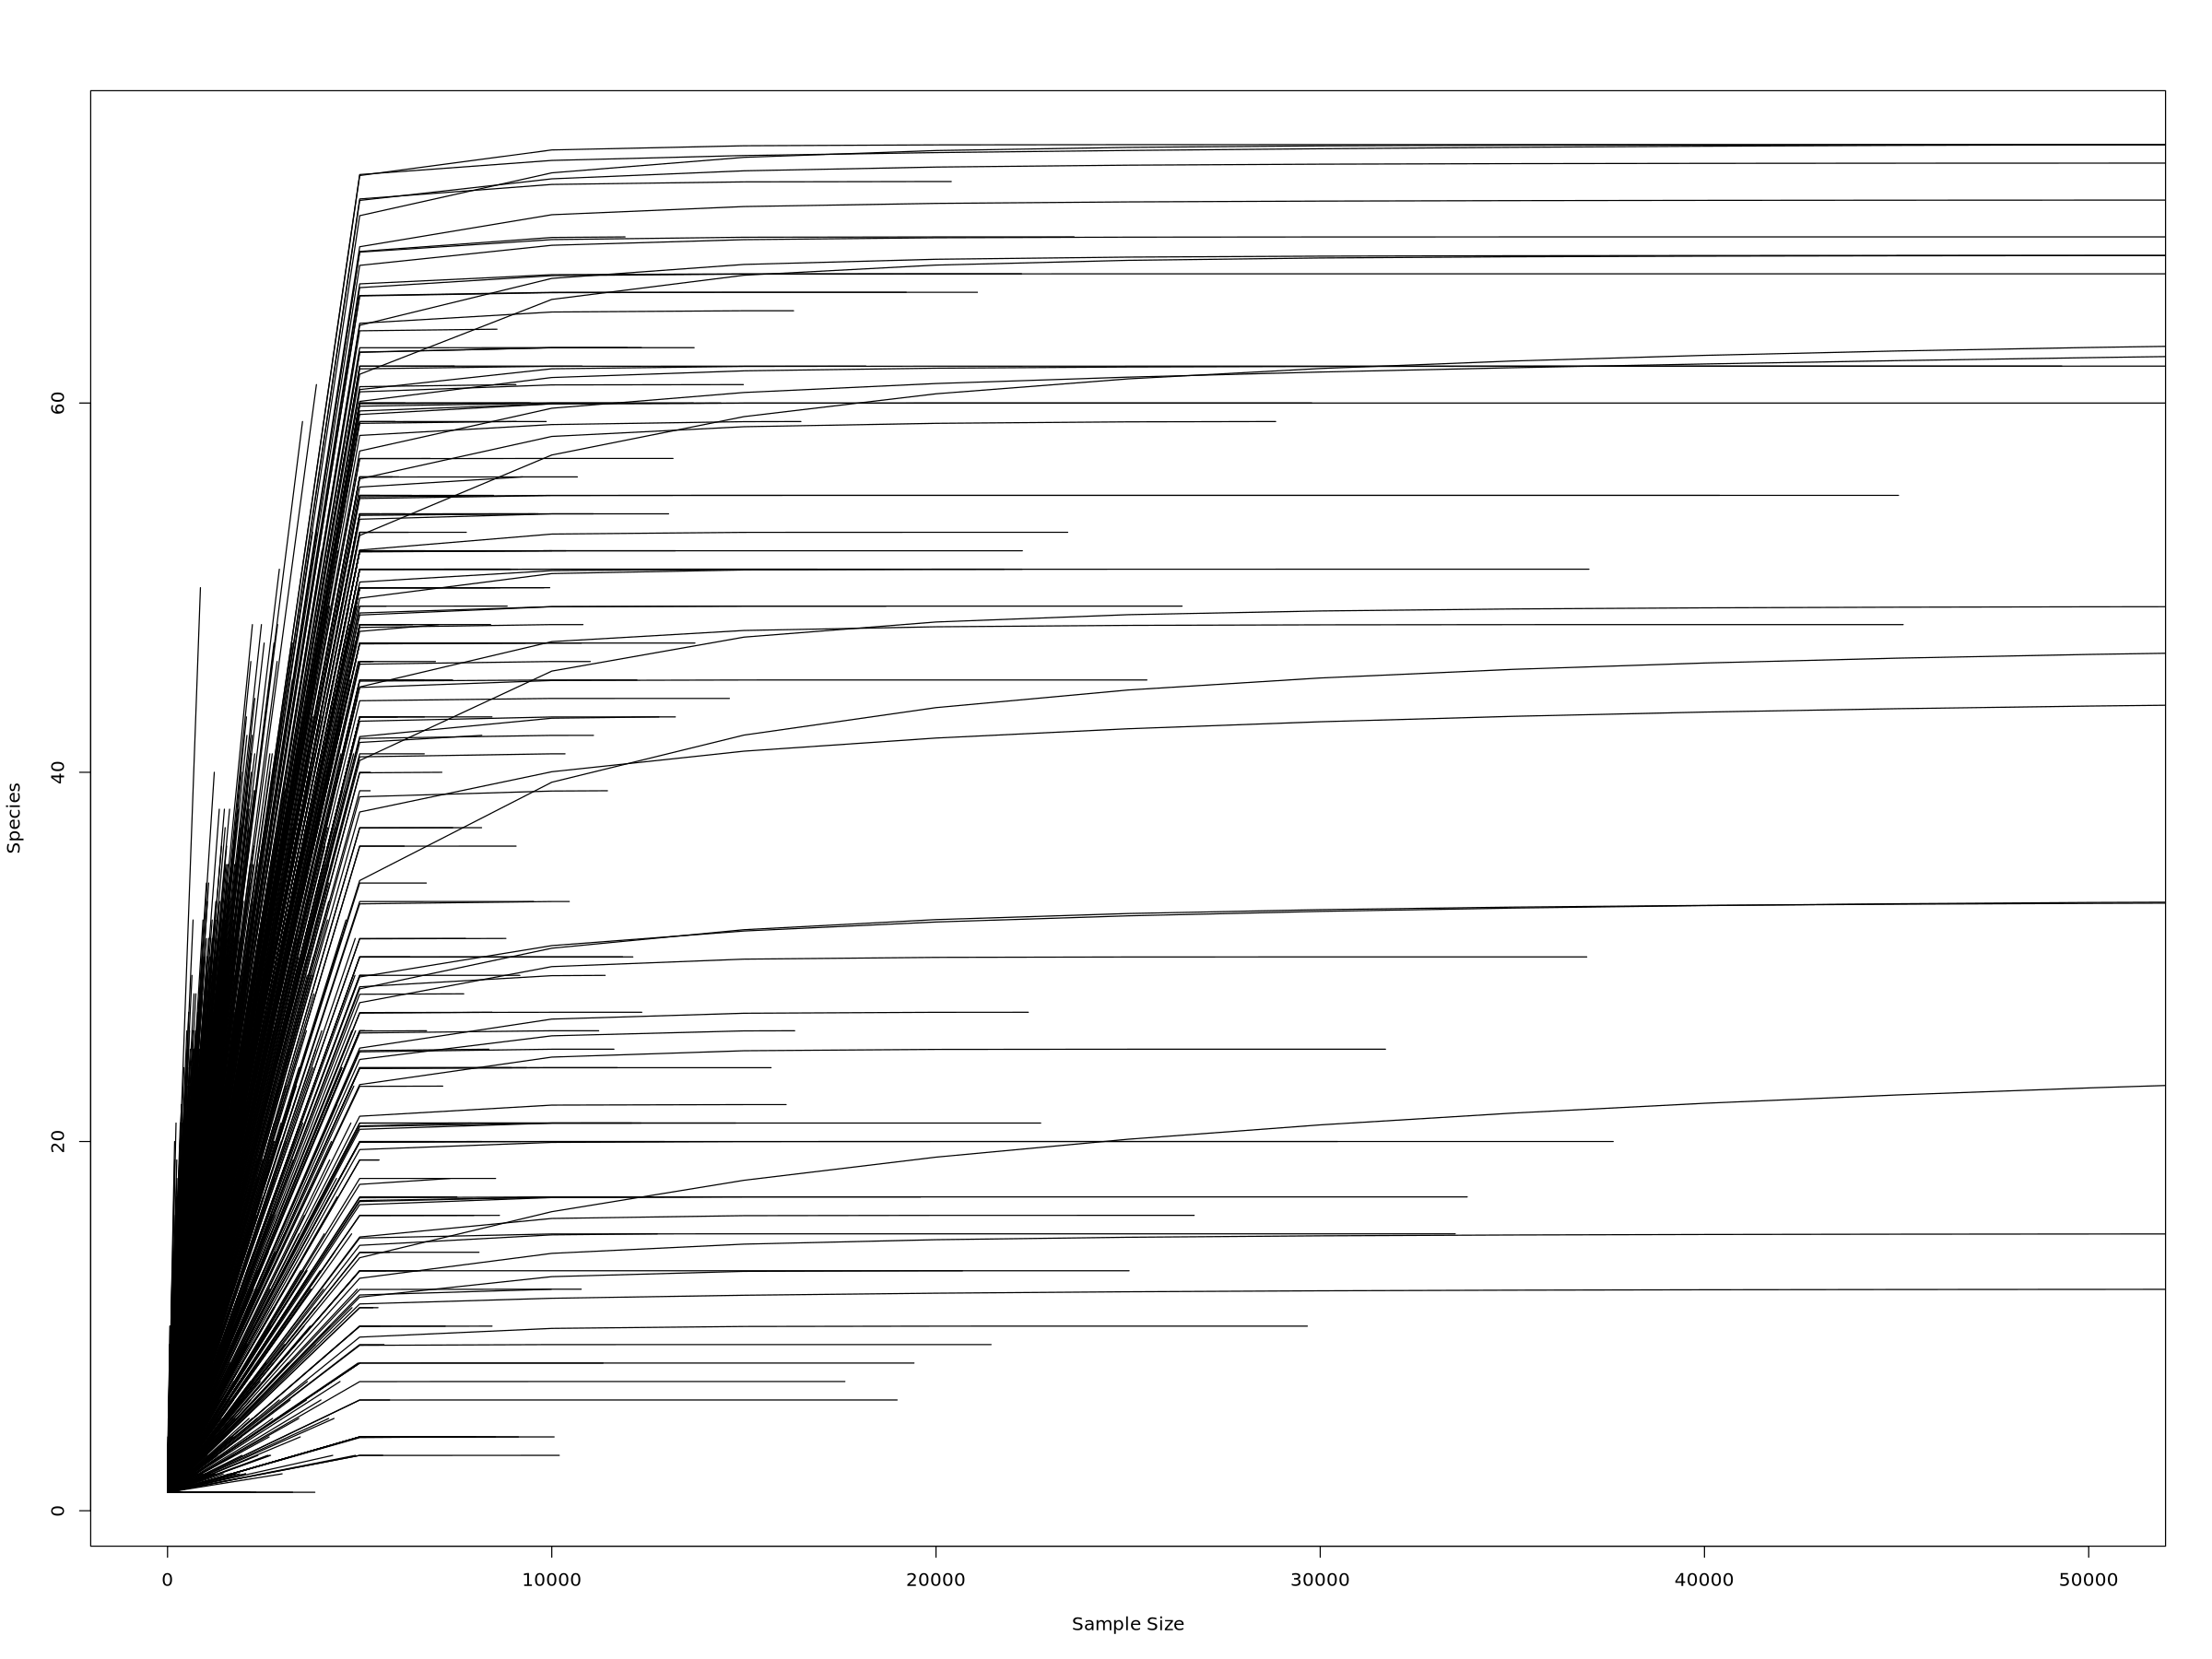

In [69]:
otu.ssid.no1 = otu_table(ps_ssid_no1)
otu.ssid.no1 = as.data.frame(t(otu.ssid.no1))
sample_names = rownames(otu.ssid.no1)

# we will use vegan rarecurve zooming in to 500K
# Zoom in directly using the xlim argument

otu.ssidcurve.no1 = rarecurve(otu.ssid.no1, step = 5000, label = FALSE, xlim = c(0, 50000))

# filtering_ps_prune_for_outliers

## filtering_threshold
- finding my ideal threshold (its 10K reads)

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


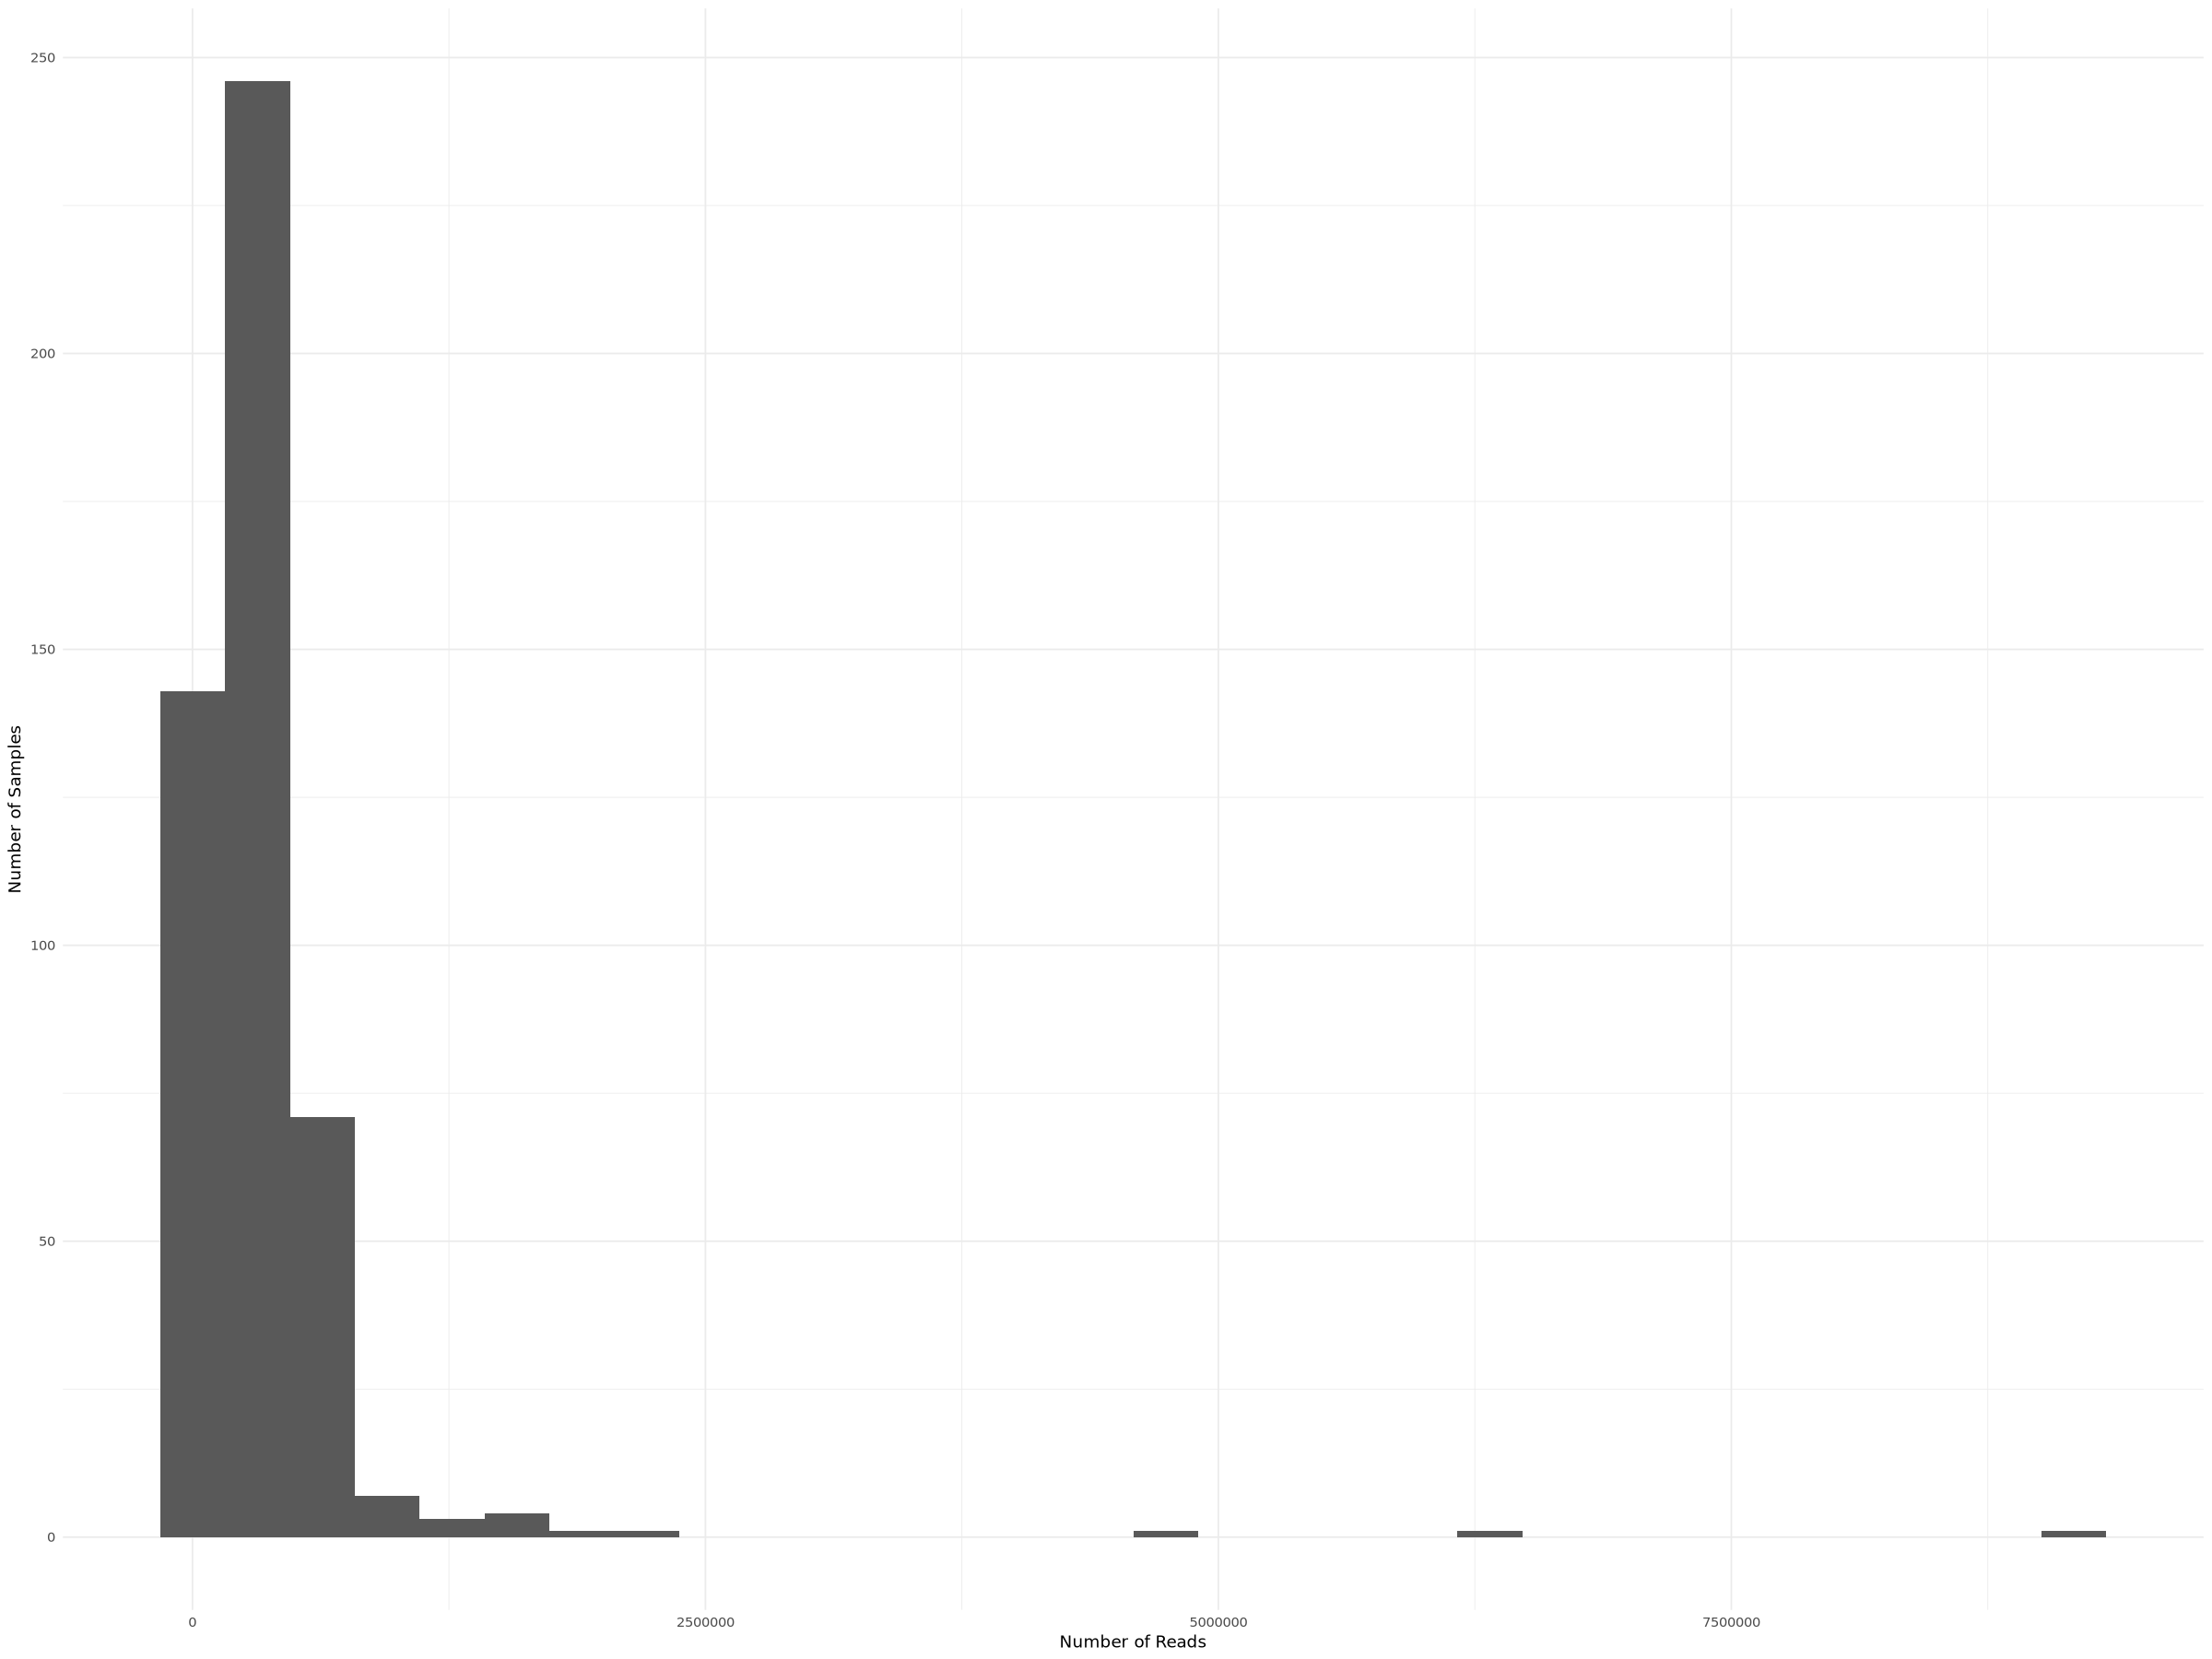

In [49]:
### where do I want to draw the filtering threshold?

readcount %>%
  ggplot(aes(x = TotalReads)) +
  geom_histogram() +   # Added width and transparency
  labs(x = "Number of Reads", y = "Number of Samples") +
  theme_minimal()

### figure notes
- most samples have under 2,500,000 reads, outliers with grater # of reads are from seq run 1

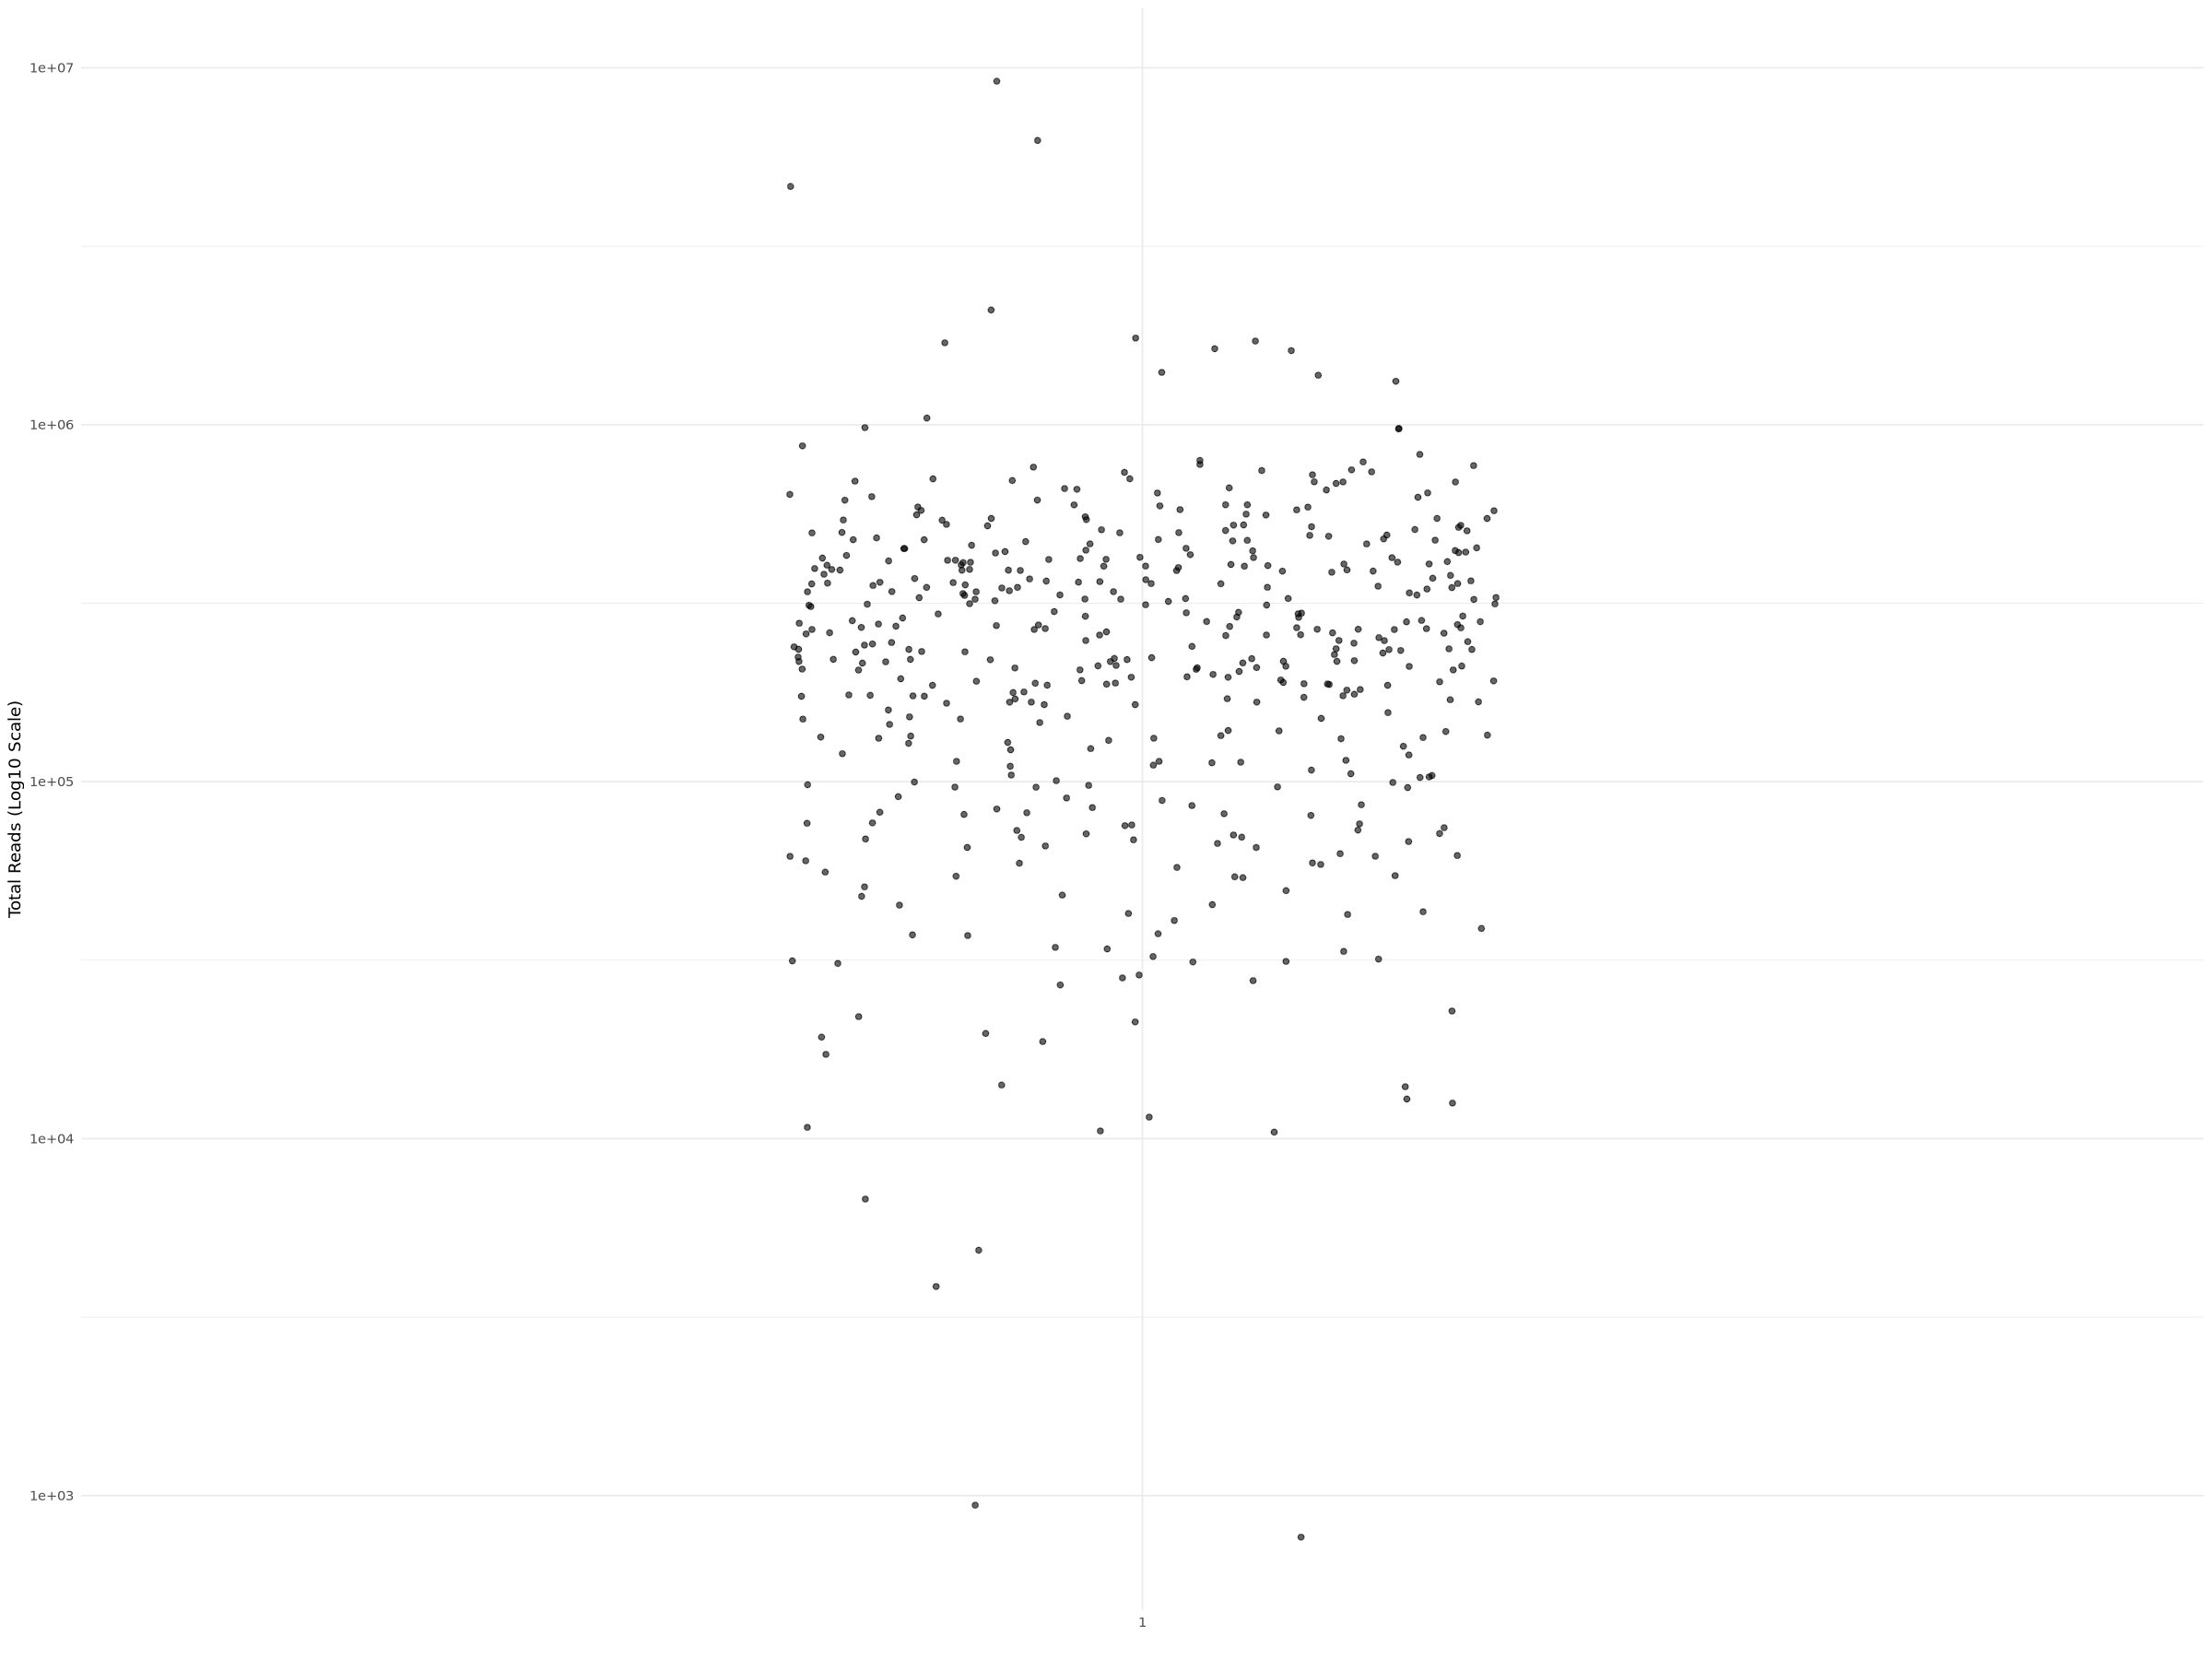

In [47]:
### where do I want to draw the filtering threshold?

readcount %>%
  ggplot(aes(x = factor(1), y = TotalReads)) +
  geom_jitter(width = 0.2, alpha = 0.6) +   # Added width and transparency
  scale_y_log10() +
  labs(x = "", y = "Total Reads (Log10 Scale)") +
  theme_minimal()


### figure notes
- most of the read counts for my samples lie between 10,000 and  1,000,000 reads
- therefore, I will filter out samples with <10K reads 

## removing_under_10K_reads 
- from original ps object (not filtered)
- removes 5 outlier samples from jitter plot


In [52]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps) >= 10000, ps)

In [53]:
# which samples were removed?
setdiff(sample_names(ps_prune), sample_names(ps_high))

[1] "122022_BEL_CBC_T3_142_MCAV" "042024_BEL_CBC_T3_960_OFAV"
[3] "Negative"                   "012024_BEL_CBC_T1_561_OANN"
[5] "Negative.4"

In [54]:
ps_high
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46551 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46551 taxa by 6 taxonomic ranks ]

### filtering_ps_high
- remove mito, chloro
- prune for singletons

In [55]:
#isolate just bacteria
ps_bac_high=subset_taxa(ps_high, Kingdom=="Bacteria")
ps_bac_high

#remove chloroplast order
ps_nochlo_high=subset_taxa(ps_bac_high, Order!="Chloroplast")
ps_nochlo_high

#remove mitochondria family
ps_nomit_high=subset_taxa(ps_nochlo_high, Family!="Mitochondria")
ps_nomit_high

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 104196 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 104196 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 78949 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 78949 taxa by 6 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46684 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46684 taxa by 6 taxonomic ranks ]

In [56]:
#removing any taxa that don't show up in any samples to speed up the process

#maybe I should up to 1 to remove singletons
ps_prune_high <- prune_taxa(taxa_sums(ps_nomit_high) > 0, ps_nomit_high)
ps_prune_high

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46536 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46536 taxa by 6 taxonomic ranks ]

# species_diversity_plots 

## chron_dates

In [74]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_prune_high)$Month_year <- factor(sample_data(ps_prune_high)$Month_year,levels = c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))

## split_species_post_10K_filter

In [75]:
ps_past_high <- subset_samples(ps_prune_high, Species == "PAST")
ps_mcav_high <- subset_samples(ps_prune_high, Species == "MCAV")
ps_pstr_high <- subset_samples(ps_prune_high, Species == "PSTR")
ps_ssid_high <- subset_samples(ps_prune_high, Species == "SSID")

## PAST

### transect

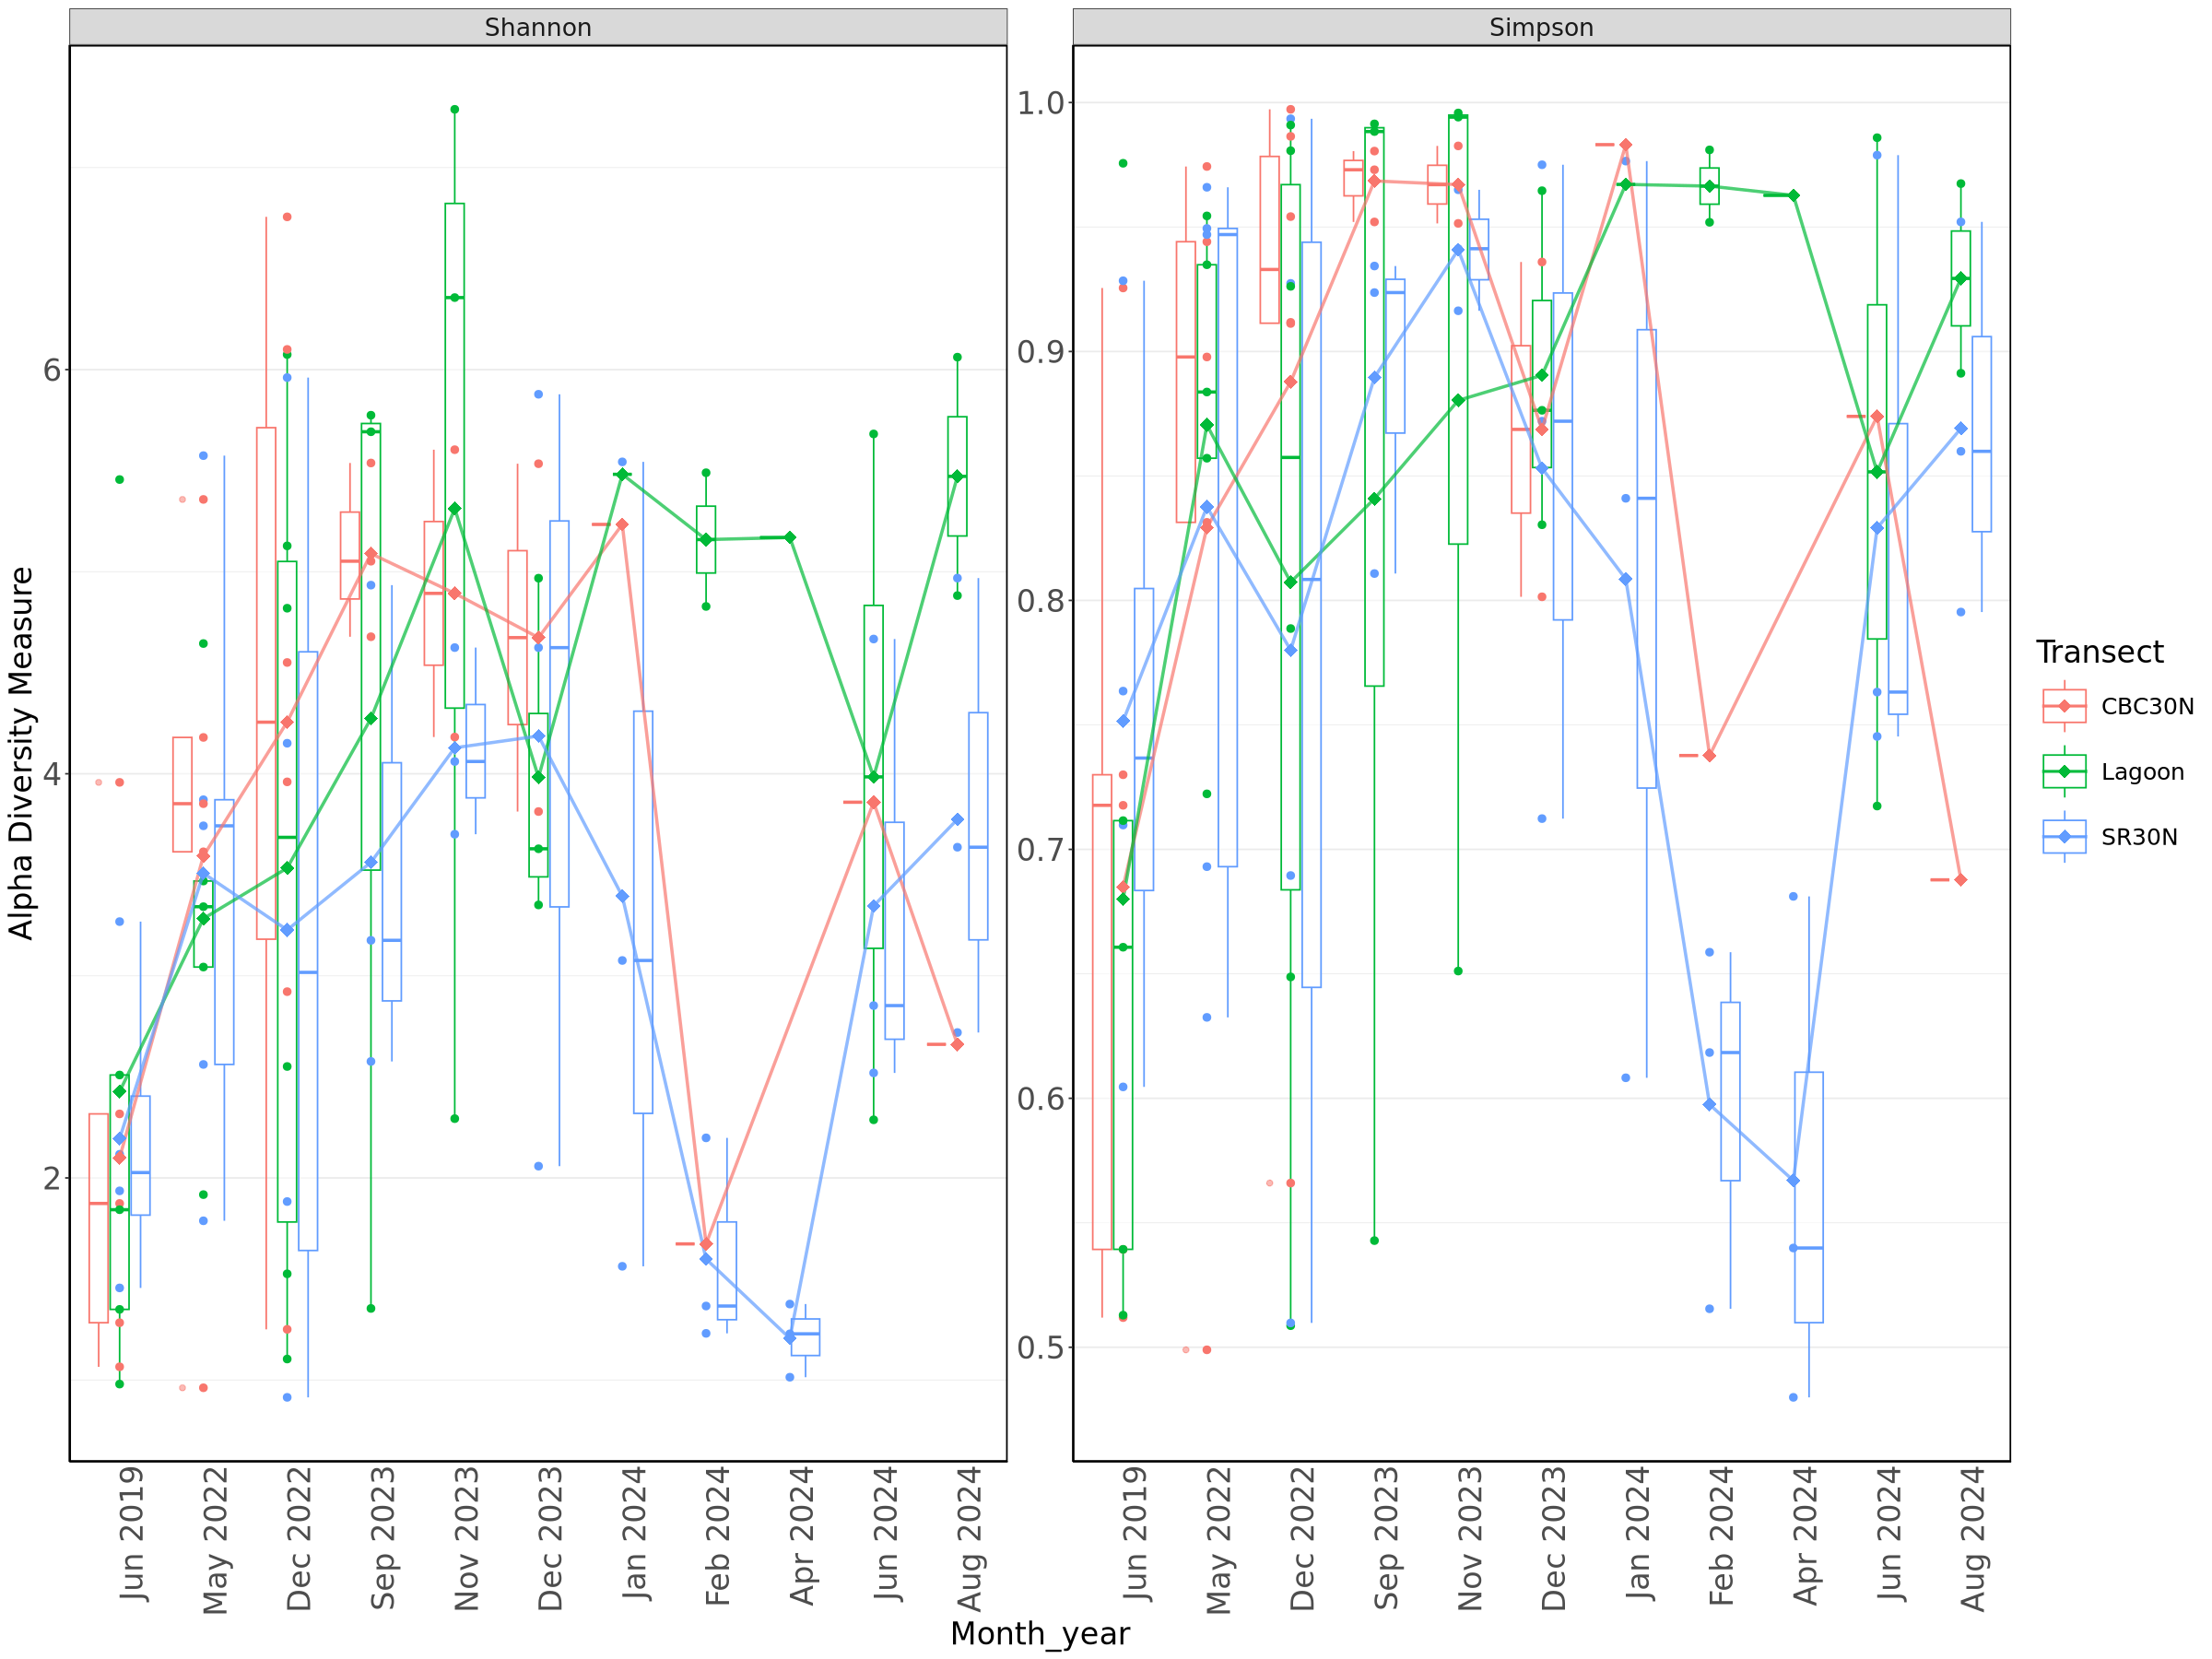

In [76]:
# Alpha diversity dot-line plot
plot_richness(ps_past_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Transect") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION ---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Transect), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Transect)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )
     

### health_status

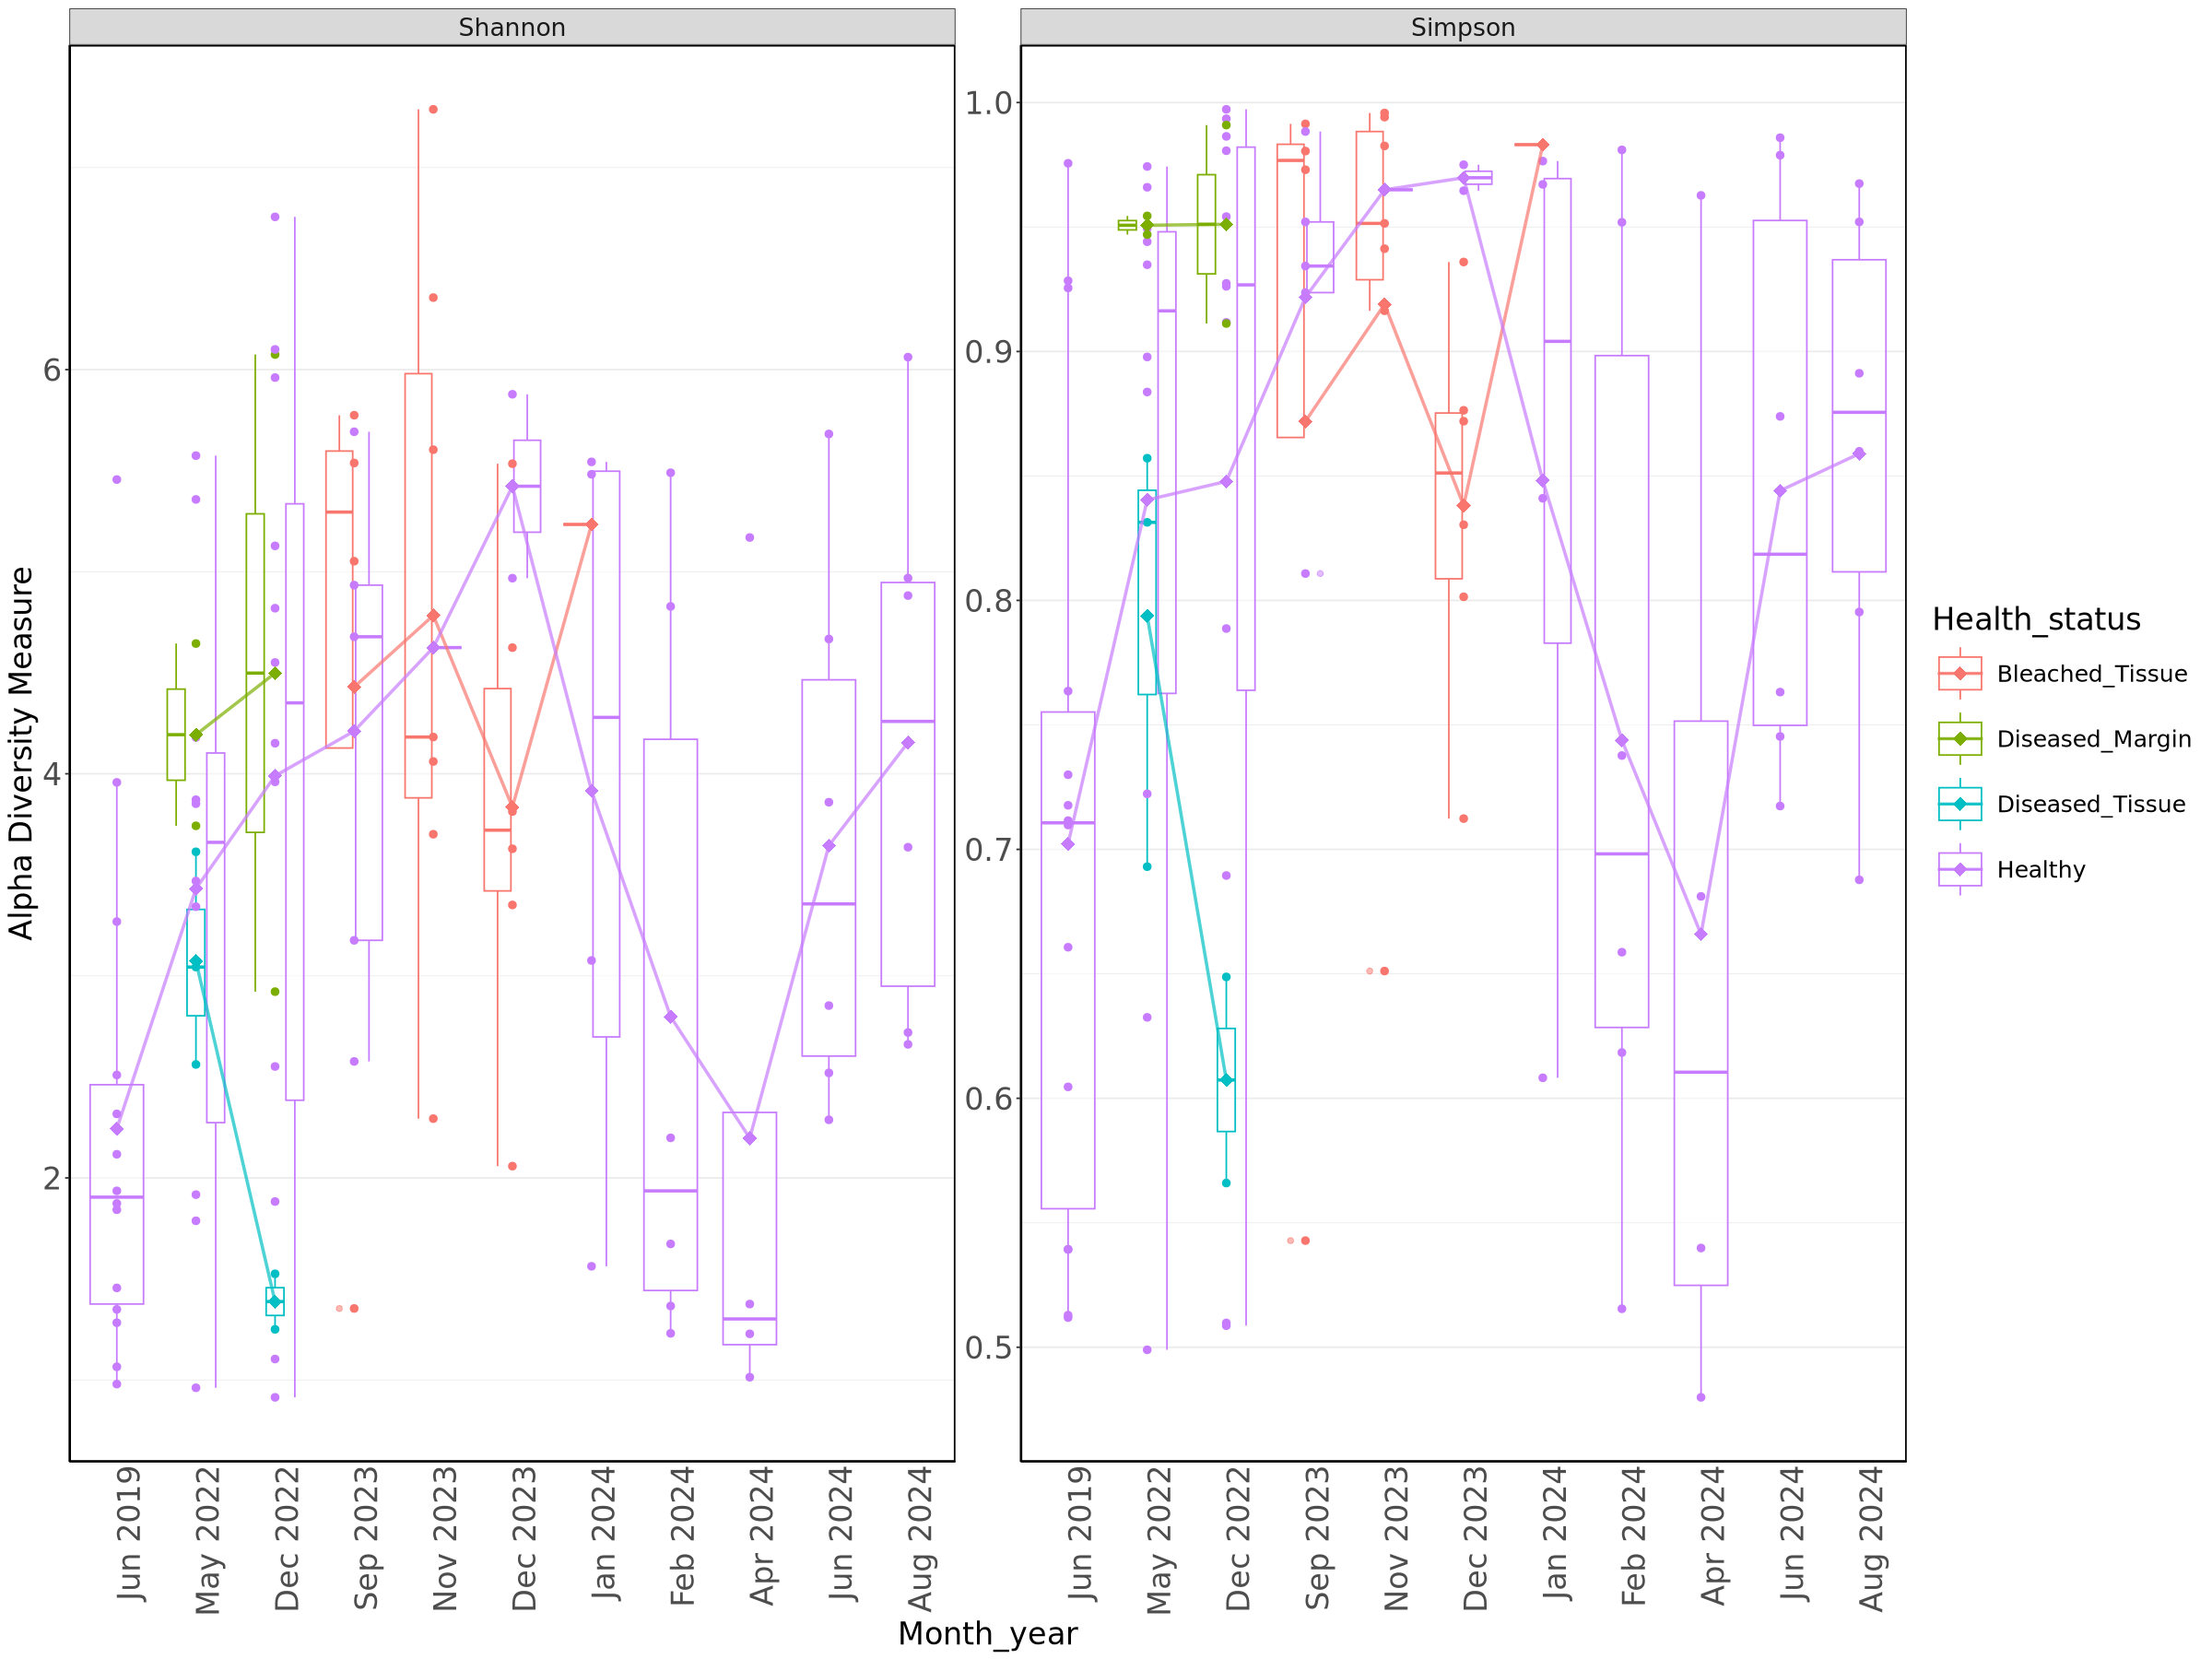

In [77]:
# Alpha diversity dot-line plot
plot_richness(ps_past_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Health_status") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION TO ADD THE MEAN AS A POINT---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Health_status), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Health_status)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )


## MCAV

### transect

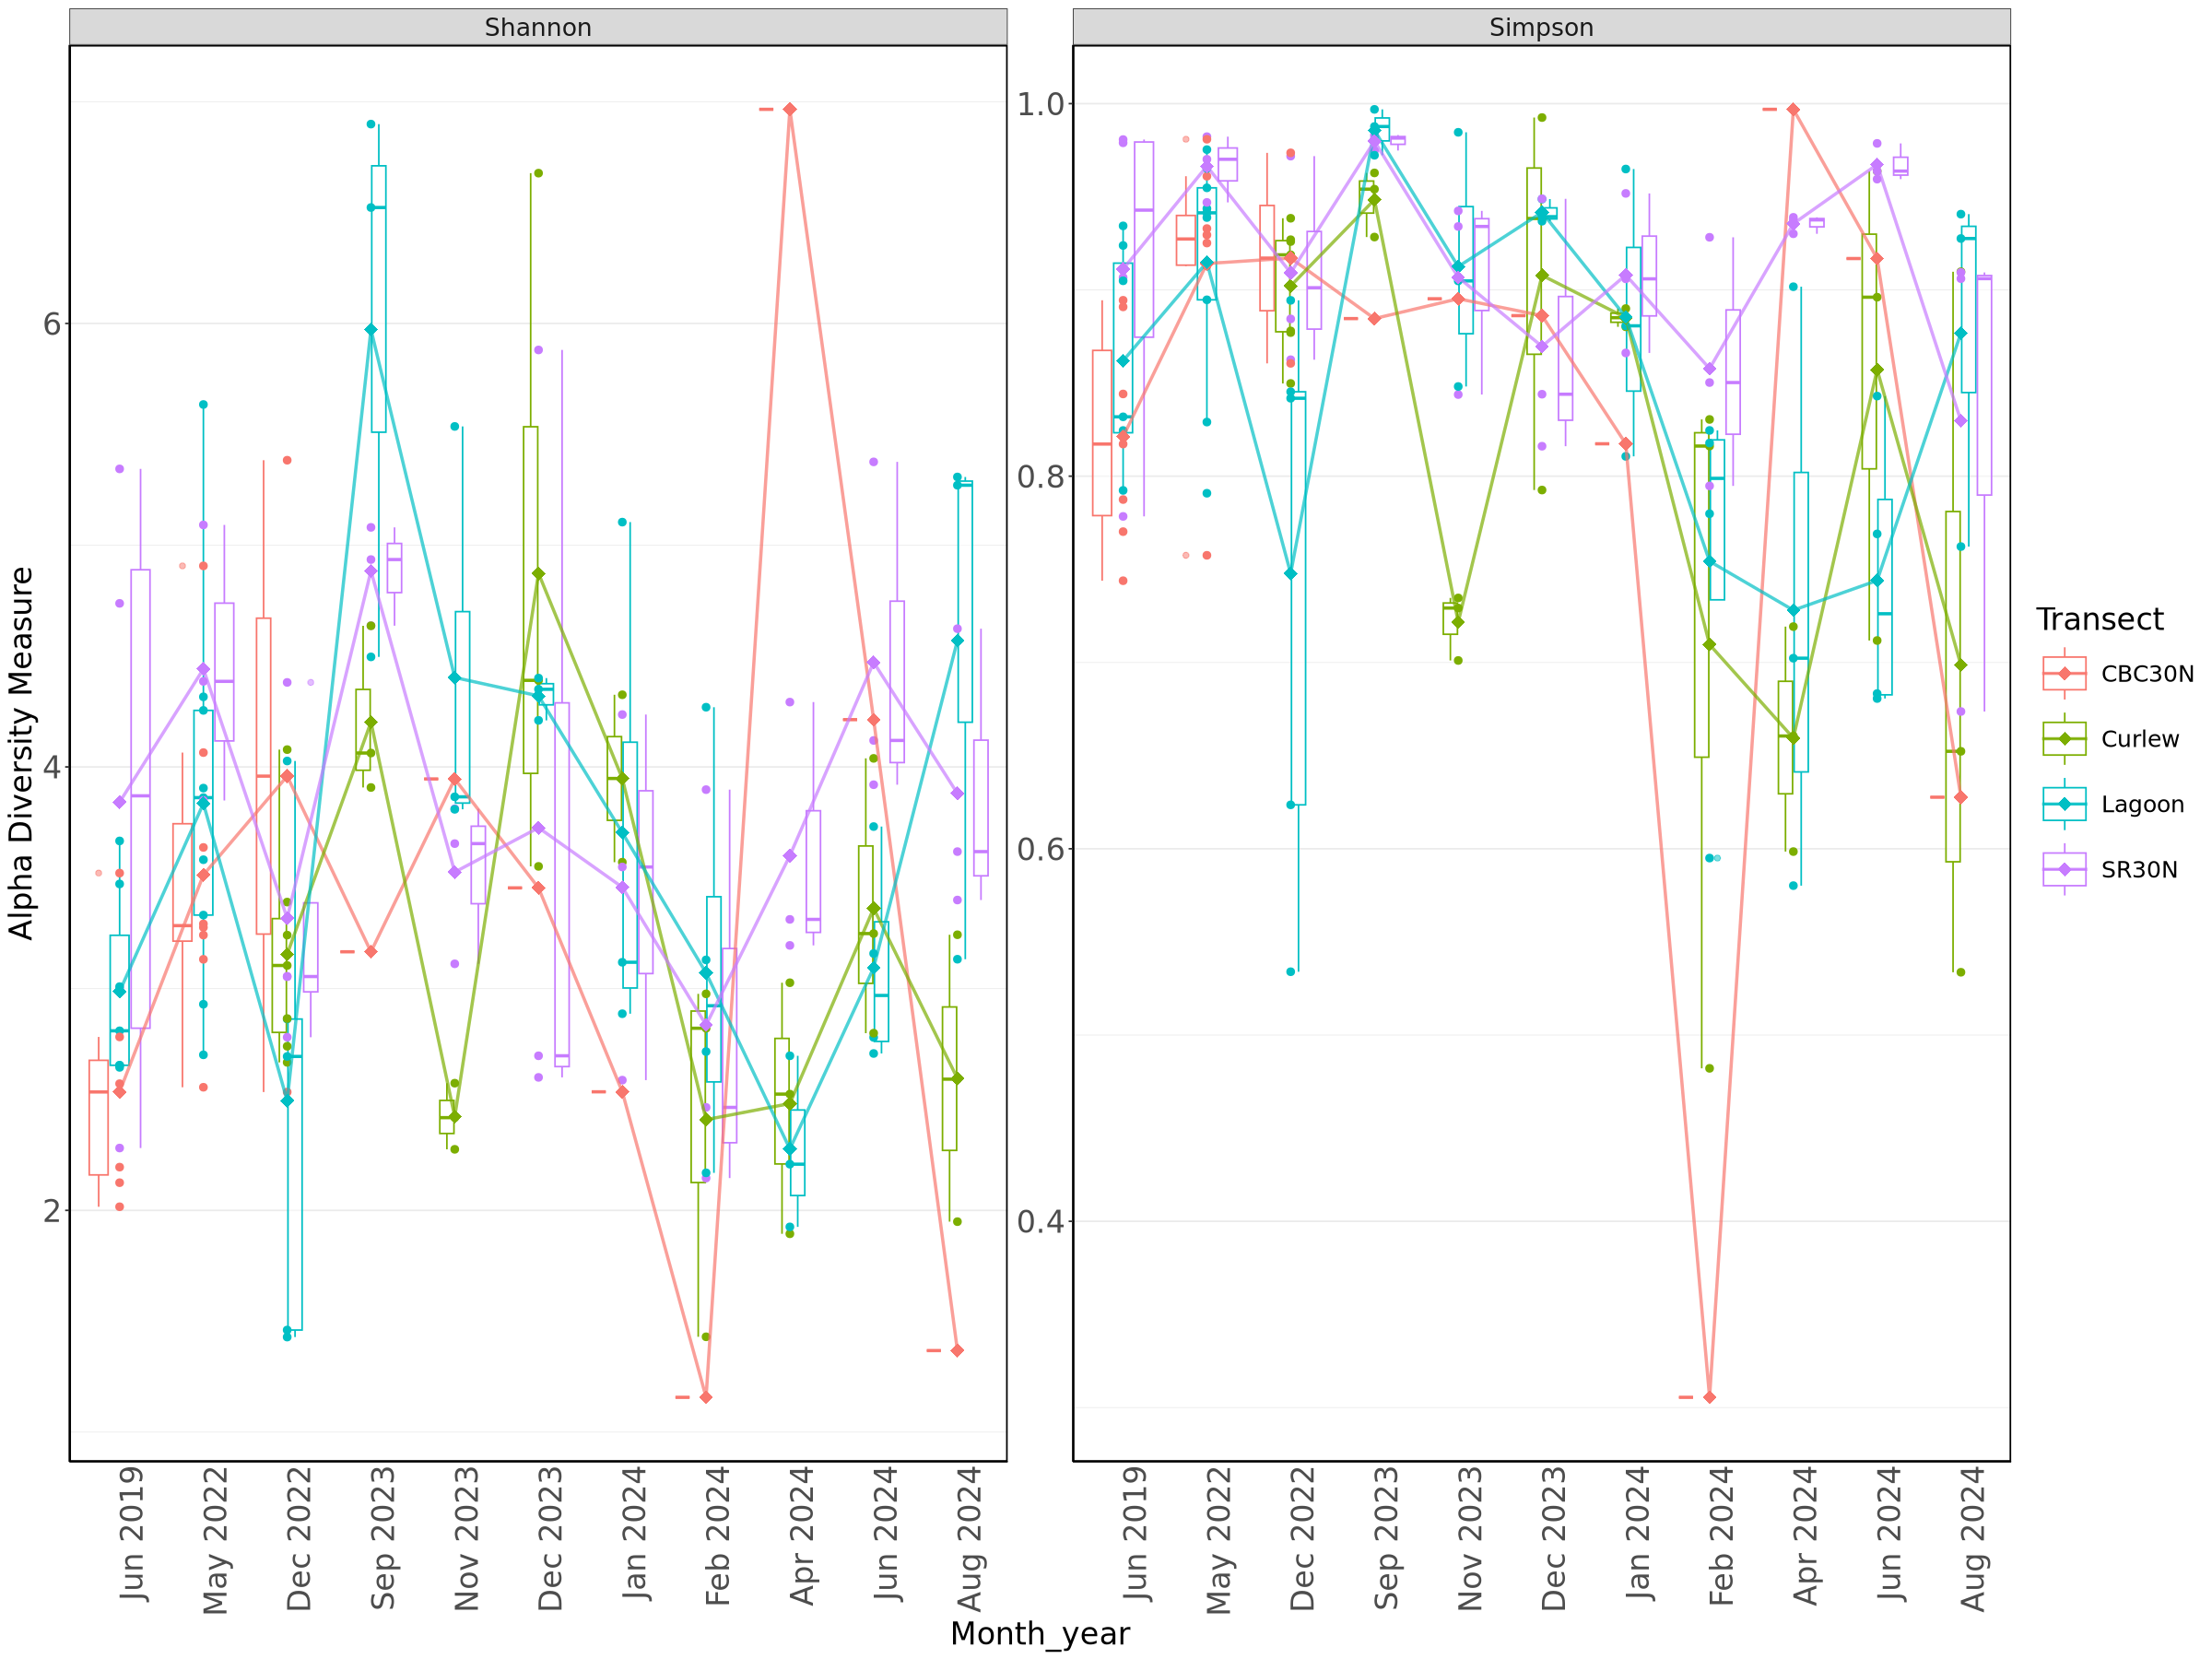

In [78]:
# Alpha diversity dot-line plot
plot_richness(ps_mcav_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Transect") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION ---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Transect), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Transect)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )

### health_status

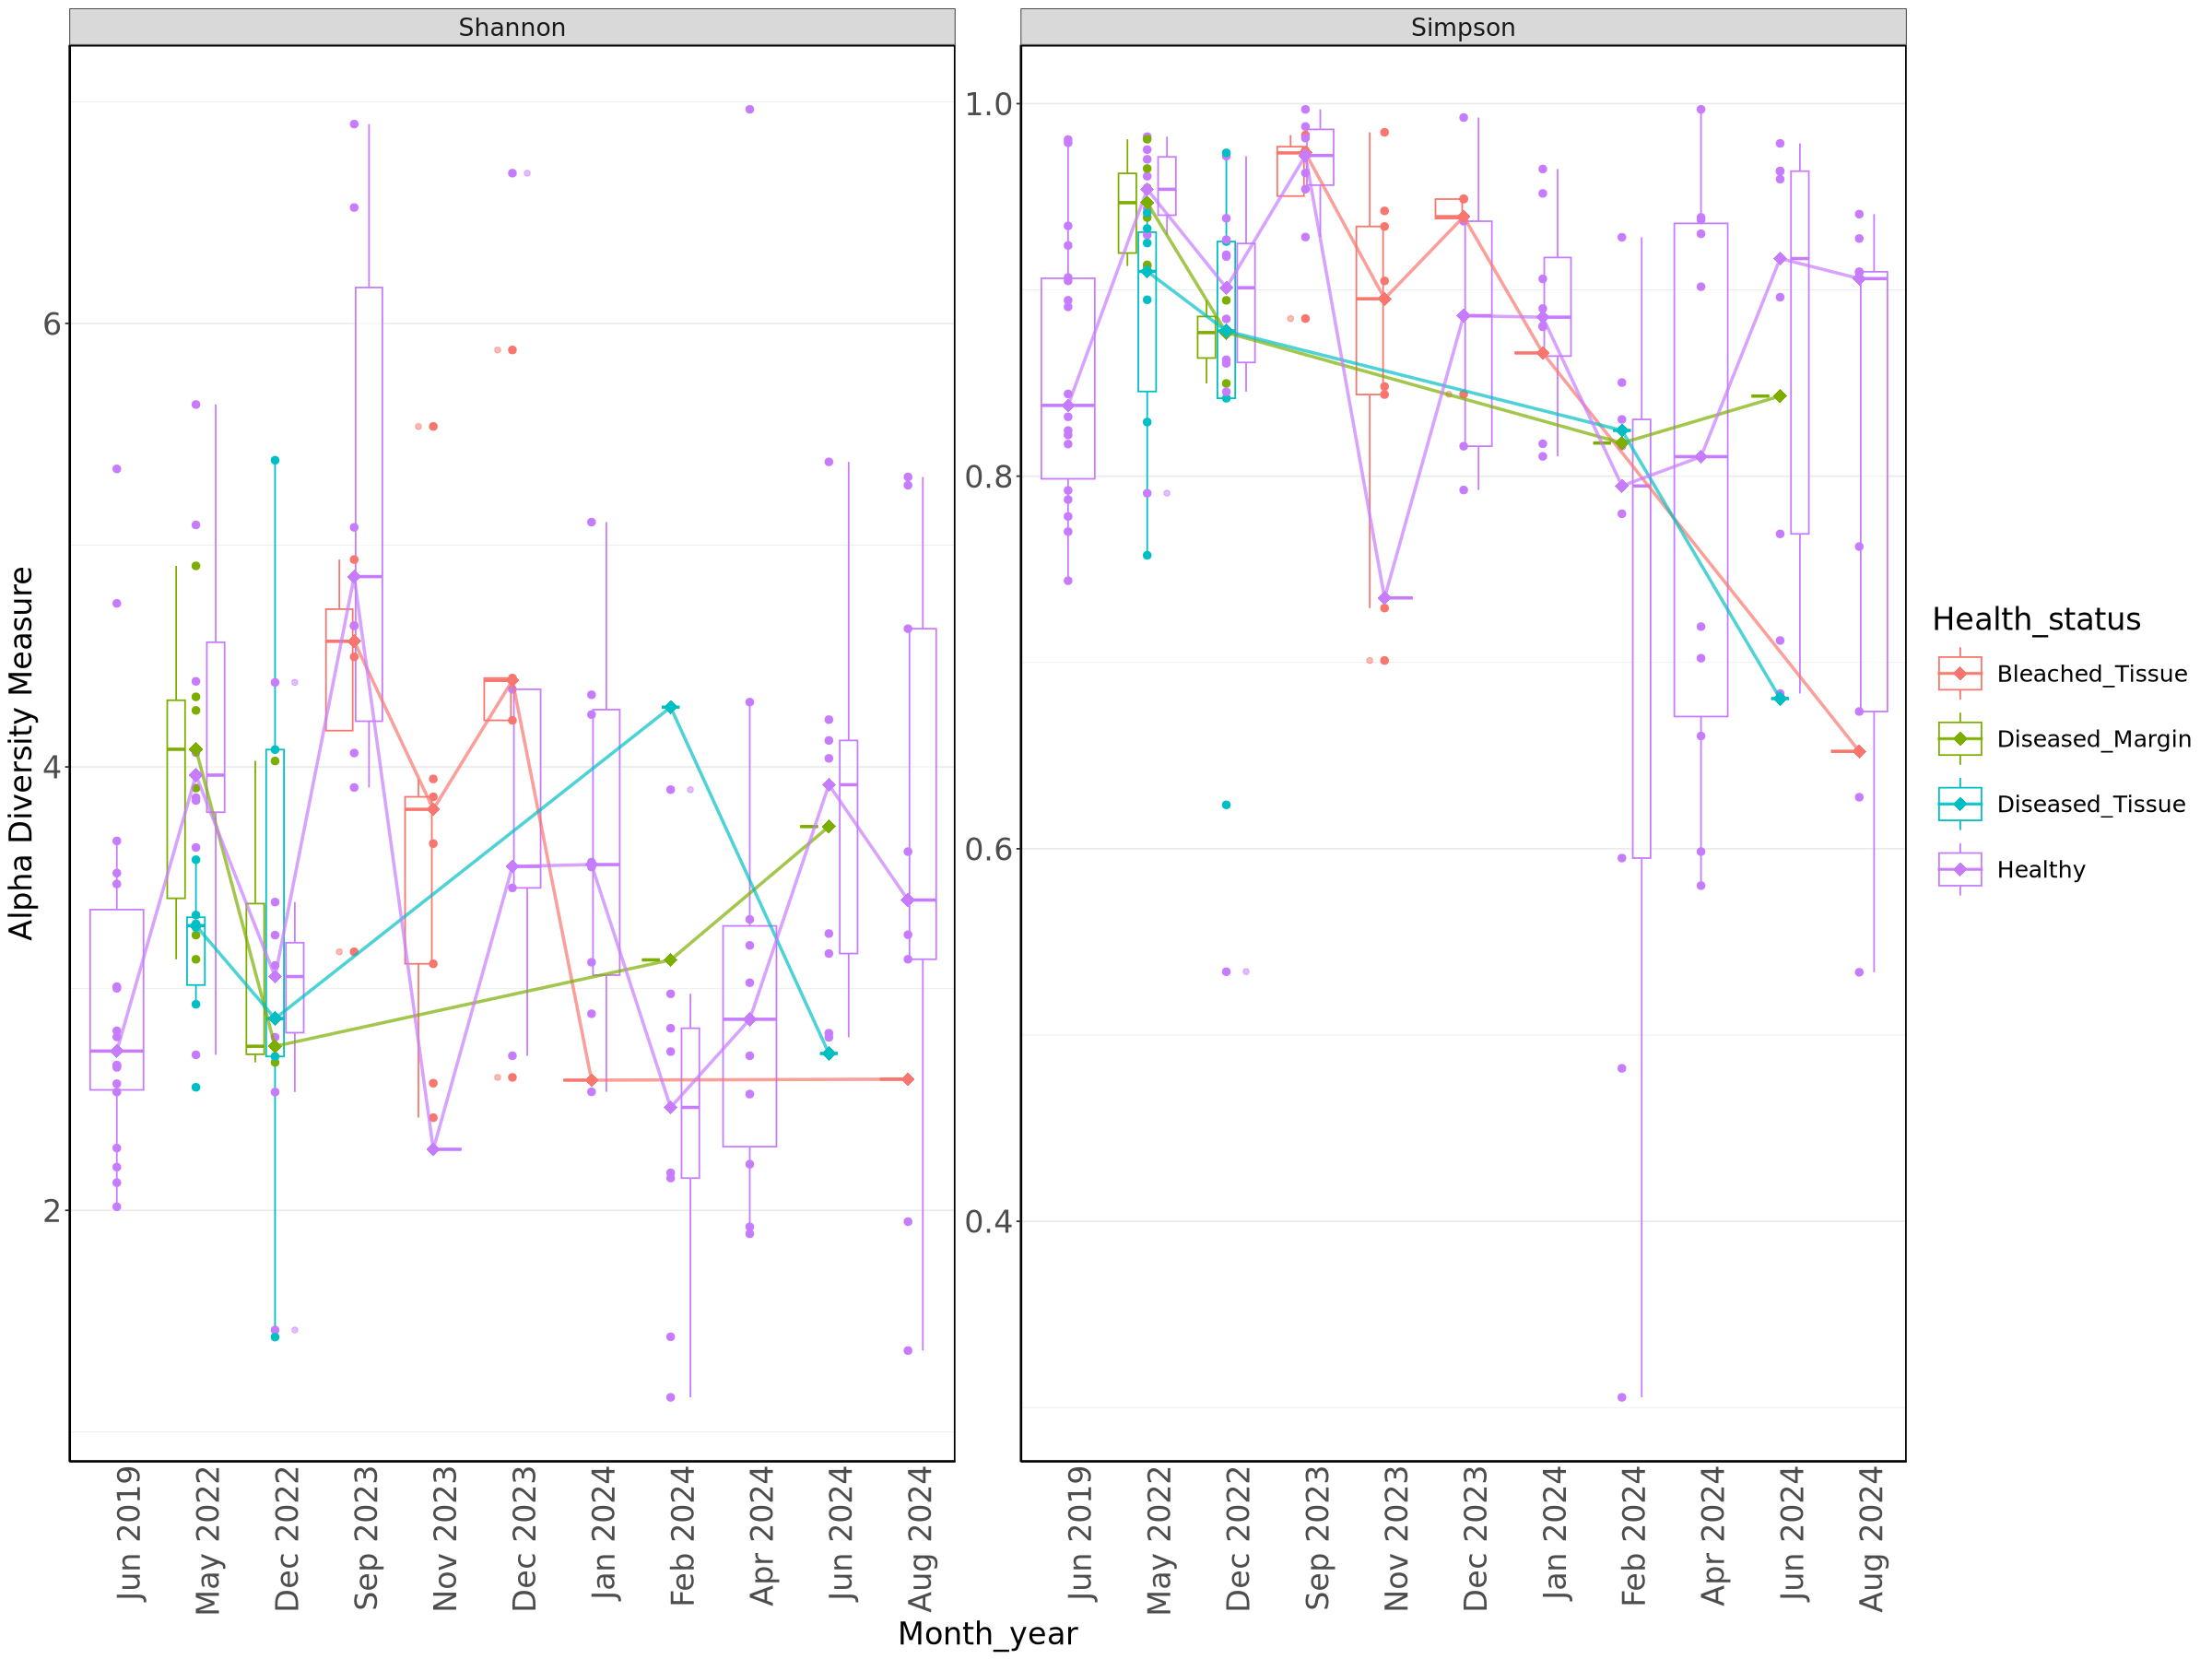

In [81]:
# Alpha diversity dot-line plot
plot_richness(ps_mcav_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Health_status") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION TO ADD THE MEAN AS A POINT---
  stat_summary(
    fun = median, 
    geom = "line", 
    aes(group = Health_status), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = median, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Health_status)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )

# network_analysis 